**Заголовок:** Исследование гендерного неравенства в заработной плате на российском рынке труда

**Описание проекта:**  
Прндставлена работа над исследовательским проектом, посвящённая анализу факторов, определяющих уровень заработной платы в России, с фокусом на гендерные различия. В основе проекта — микроданные 32-й волны (2023 год) Российского мониторинга экономического положения и здоровья населения (RLMS‑HSE). Цель исследования — не только оценить масштаб гендерного разрыва в оплате труда, но и выявить, какие социально-демографические, профессиональные, институциональные и психологические факторы влияют на доход, а также сравнить предсказательную силу различных эконометрических и машинных моделей. Дополнительно проект включает кластеризацию работников для выделения однородных групп и их характеристики.

**Цель исследования:**  
Выявление ключевых детерминант заработной платы в России, количественная оценка гендерного разрыва с учётом контроля различных факторов, построение и сравнение прогностических моделей (от линейной регрессии до бустингов), а также проведение кластеризации для сегментации работников по социально-экономическим признакам.

**Ход исследования:**

1. **Предобработка данных:**
   - Загрузка и первичный анализ микроданных RLMS‑HSE (11820 наблюдений).
   - Выявление и обработка артефактов, замена / удаление пропусков.
   - Построение распределений ключевых переменных (доход, возраст, образование, стаж и др.).
   - Логарифмическое преобразование переменной дохода (`log_salary`) для учёта относительных различий и снижения влияния выбросов.
   - Анализ репрезентативности выборки в гендерном аспекте (54% женщин, 46% мужчин, что соответствует структуре Росстата).

2. **Анализ мультиколлинеарности и отбор признаков:**
   - Проверка мультиколлинеарности через корреляцию Пирсона и VIF‑тест.
   - Отбор важных признаков с помощью Random Forest Regressor (учёт нелинейных и интерактивных эффектов, устойчивость к выбросам и коррелированным предикторам).

3. **Построение линейных регрессионных моделей (спецификации на основе уравнения Минсера):**
   - **Спецификация 1:** с возрастом и его квадратом.
   - **Спецификация 2:** с опытом работы вместо возраста.
   - **Спецификация 3:** расширенная — дополнена социально-демографическими (семейный статус, наличие детей), институциональными (регион, тип населённого пункта) и психологическими (удовлетворённость работой) переменными.
   - Проверка каждой модели на гетероскедастичность (с применением поправок Уайта), мультиколлинеарность (VIF) и правильность спецификации (RESET-тест).
   - Анализ перекрёстных переменных (interaction terms).
   - Тест Чоу для проверки гипотезы о различии механизмов формирования зарплаты для мужчин и женщин (p-value < 0.05).

4. **Построение и сравнение прогностических моделей:**
   - Линейные модели: OLS, Lasso (L1-регуляризация с подбором α через GridSearchCV), Ridge (L2-регуляризация).
   - Деревья решений и ансамбли: Decision Tree Regression, Random Forest Regression.
   - Бустинговые модели: Gradient Boosting, XGBoost (с контролем гиперпараметров: `subsample`, `colsample_bytree`, `n_estimators`).
   - Для каждой модели вывод важности признаков (или коэффициентов) и расчёт метрик: RMSE, MAE.
   - Сравнительный анализ: установлено, что разница в точности между моделями минимальна (около 0.5% по RMSE), что говорит о преобладании линейных зависимостей и отсутствии серьёзной мультиколлинеарности.

5. **Кластеризация работников:**
   - Выбор оптимального числа кластеров с помощью метода локтя (inertia) и силуэтного коэффициента (silhouette score).
   - Применение алгоритма k-means с `n_init=10` для устойчивости.
   - Анализ распределения признаков по кластерам (средние и медианные значения).
   - Визуализация центров кластеров с помощью PCA (снижение размерности до двух главных компонент).

**Общий вывод:**  
В проекте выполнена полная аналитическая цепочка — от очистки реальных микроданных до построения регрессионных и прогностических моделей, а также кластеризации. Установлено, что даже после контроля широкого набора факторов гендерный разрыв в зарплате сохраняется на уровне 25–26%. При этом механизмы формирования заработной платы для мужчин и женщин статистически различны (тест Чоу). Сравнение прогностических моделей показало, что сложные алгоритмы (случайный лес, бустинг) не дают значимого выигрыша в точности перед линейной регрессией, что указывает на линейную природу основных зависимостей. Кластеризация позволила выделить однородные группы работников с близкими социально-экономическими характеристиками и уровнями дохода.

# Анализ данных

# Предобработка даных

## Загрузка данных

In [5]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tools.tools as smt
import statsmodels.stats.diagnostic as smd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
import phik
from phik.report import plot_correlation_matrix
from phik import report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
from scipy import stats
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [7]:
df=pd.read_csv('short.csv', sep=';')

In [8]:
pd.set_option('display.max_columns', None) # вывод всех колонок

In [9]:
pd.set_option('display.float_format', '{:.2f}'.format) # избавимся от экспоненциальных даных в описательной статистике

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11820 entries, 0 to 11819
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Idind       11820 non-null  int64  
 1   Psu         11820 non-null  int64  
 2   Status      11820 non-null  int64  
 3   Bb_Marst    10174 non-null  float64
 4   Bb_Occup08  5172 non-null   float64
 5   Bb_Diplom   10174 non-null  float64
 6   Bb_Age      11820 non-null  object 
 7   Bbh5        11820 non-null  int64  
 8   Bbi3        4511 non-null   float64
 9   Bbj1        10174 non-null  float64
 10  Bbj1_1_1    5172 non-null   float64
 11  Bbj1_1_2    5172 non-null   float64
 12  Bbj1_1_3    5172 non-null   float64
 13  Bbj1_1_4    5172 non-null   float64
 14  Bbj4_1      5172 non-null   float64
 15  Bbj6_2      5172 non-null   float64
 16  Bbj13       4681 non-null   float64
 17  Bbj13_2     4681 non-null   float64
 18  Bbj21_3     4681 non-null   float64
 19  Bbj23       4681 non-null

Исходный набор данных включал демографические, профессиональные, образовательные и психологические показатели, такие как возраст, пол, стаж, образование, уровень дохода, удовлетворенность работой и здоровье, в данных 11820 строк.

In [12]:
df

,Idind,Psu,Status,Bb_Marst,Bb_Occup08,Bb_Diplom,Bb_Age,Bbh5,Bbi3,Bbj1,Bbj1_1_1,Bbj1_1_2,Bbj1_1_3,Bbj1_1_4,Bbj4_1,Bbj6_2,Bbj13,Bbj13_2,Bbj21_3,Bbj23,Bbj24,Bbj26,Bbj29c_1,Bbj29c_2,Bbj22,Bbj65,Bbj66_1,Bbj72_18a,Bbj72_11,Bbj260,Bbj72_172,Bbj161_3y,Bbm3,Bbm20_7,Bbm131
0,7,6,3,1.00,NaN,3.00,79,2,1.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,3.00,1.00,2.00,2.00,NaN,40.00,3,1,2
1,92,6,4,2.00,NaN,4.00,65,2,3.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,4.00,5.00,2.00,2.00,3.00,39.00,3,2,2
2,93,6,4,2.00,5.00,4.00,"69,5",1,3.00,1.00,2.00,2.00,2.00,2.00,13.00,48.00,80.00,35000.00,1.00,1.00,2.00,2.00,2.00,2.00,5.00,2.00,2.00,3.00,2.00,2.00,3.00,41.00,2,2,2
3,95,6,4,5.00,NaN,1.00,"95,5",2,3.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,1.00,2.00,2.00,3.00,39.00,3,2,2
4,102,6,4,2.00,NaN,5.00,69,2,1.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,6.00,2.00,2.00,2.00,44.00,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11815,63954,2,1,5.00,NaN,2.00,"84,5",2,1.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,1.00,2.00,2.00,3.00,37.00,4,2,2
11816,63955,3,2,3.00,5.00,5.00,"20,5",2,1.00,1.00,1.00,1.00,2.00,2.00,1.00,32.00,4.00,28000.00,2.00,1.00,2.00,2.00,2.00,5.00,1.00,1.00,3.00,6.00,2.00,2.00,NaN,0.00,2,2,1
11817,63956,7,1,1.00,NaN,5.00,19,1,2.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,4.00,2.00,2.00,2.00,NaN,NaN,2,2,2
11818,63957,7,1,2.00,5.00,4.00,58,1,NaN,1.00,1.00,3.00,1.00,99999997.00,13.00,48.00,300.00,26000.00,2.00,2.00,2.00,2.00,1.00,2.00,4.00,2.00,2.00,5.00,1.00,2.00,2.00,41.00,2,2,2


In [13]:
df.rename(columns = {'Idind': 'id', 'Psu':'region', 'Status': 'locality', 'Bb_Marst': 'marital_status', \
                     'Bb_Occup08': 'occupation', 'Bb_Diplom': 'edu', 'Bb_Age': 'age', 'Bbh5': 'male', 'Bbi3': 'birthplace', \
                    'Bbj1': 'employment', 'Bbj1_1_1': 'job_satisfaction', 'Bbj1_1_2': 'labour_conditions_satisfaction', \
                    'Bbj1_1_3': 'salary_satisfaction', 'Bbj1_1_4': 'promotion_satisfaction', 'Bbj4_1': 'industry', \
                    'Bbj6_2': 'work_schedule', 'Bbj13': 'organization_size', 'Bbj13_2': 'salary', 'Bbj21_3': 'hazardous_industry', \
                    'Bbj23': 'state_owner', 'Bbj24': 'foreign_owner', 'Bbj26': 'self_owner', 'Bbj29c_1': 'management_trust', \
                    'Bbj29c_2': 'colleagues_trust', 'Bbj22': 'new_job_confidence', 'Bbj65': 'life_satisfaction', \
                    'Bbj66_1': 'financial_situation_satisfaction', 'Bbj72_18a': 'diplom', 'Bbj72_11': 'courses', \
                    'Bbj260': 'foreign_language', 'Bbj72_172': 'kids', 'Bbj161_3y': 'experience', 'Bbm3': 'health', \
                    'Bbm20_7': 'disability', 'Bbm131': 'depression'}, inplace = True) # переименуем колонки для читабельности

In [14]:
df

,id,region,locality,marital_status,occupation,edu,age,male,birthplace,employment,job_satisfaction,labour_conditions_satisfaction,salary_satisfaction,promotion_satisfaction,industry,work_schedule,organization_size,salary,hazardous_industry,state_owner,foreign_owner,self_owner,management_trust,colleagues_trust,new_job_confidence,life_satisfaction,financial_situation_satisfaction,diplom,courses,foreign_language,kids,experience,health,disability,depression
0,7,6,3,1.00,NaN,3.00,79,2,1.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,3.00,1.00,2.00,2.00,NaN,40.00,3,1,2
1,92,6,4,2.00,NaN,4.00,65,2,3.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,4.00,5.00,2.00,2.00,3.00,39.00,3,2,2
2,93,6,4,2.00,5.00,4.00,"69,5",1,3.00,1.00,2.00,2.00,2.00,2.00,13.00,48.00,80.00,35000.00,1.00,1.00,2.00,2.00,2.00,2.00,5.00,2.00,2.00,3.00,2.00,2.00,3.00,41.00,2,2,2
3,95,6,4,5.00,NaN,1.00,"95,5",2,3.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,1.00,2.00,2.00,3.00,39.00,3,2,2
4,102,6,4,2.00,NaN,5.00,69,2,1.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,6.00,2.00,2.00,2.00,44.00,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11815,63954,2,1,5.00,NaN,2.00,"84,5",2,1.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,1.00,2.00,2.00,3.00,37.00,4,2,2
11816,63955,3,2,3.00,5.00,5.00,"20,5",2,1.00,1.00,1.00,1.00,2.00,2.00,1.00,32.00,4.00,28000.00,2.00,1.00,2.00,2.00,2.00,5.00,1.00,1.00,3.00,6.00,2.00,2.00,NaN,0.00,2,2,1
11817,63956,7,1,1.00,NaN,5.00,19,1,2.00,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,4.00,2.00,2.00,2.00,NaN,NaN,2,2,2
11818,63957,7,1,2.00,5.00,4.00,58,1,NaN,1.00,1.00,3.00,1.00,99999997.00,13.00,48.00,300.00,26000.00,2.00,2.00,2.00,2.00,1.00,2.00,4.00,2.00,2.00,5.00,1.00,2.00,2.00,41.00,2,2,2


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11820 entries, 0 to 11819
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                11820 non-null  int64  
 1   region                            11820 non-null  int64  
 2   locality                          11820 non-null  int64  
 3   marital_status                    10174 non-null  float64
 4   occupation                        5172 non-null   float64
 5   edu                               10174 non-null  float64
 6   age                               11820 non-null  object 
 7   male                              11820 non-null  int64  
 8   birthplace                        4511 non-null   float64
 9   employment                        10174 non-null  float64
 10  job_satisfaction                  5172 non-null   float64
 11  labour_conditions_satisfaction    5172 non-null   float64
 12  sala

In [16]:
df['age'] = df['age'].str.replace(',', '.').astype(float) # приводим количественные показатели к корректному формату

In [17]:
df[df['occupation'] == 1]['male'].value_counts()

male
1    154
2    130
Name: count, dtype: int64

## Работа с данными

### Заработная плата

In [20]:
df['salary'].describe()

count       4681.00
mean     7344408.20
std     26015756.47
min            0.00
25%        25000.00
50%        37000.00
75%        58000.00
max     99999999.00
Name: salary, dtype: float64

In [21]:
problem = len(df[(df['salary'] == 99999999.00) | (df['salary'] == 99999998.00) | (df['salary'] == 99999997.00) | (df['salary'] == 99999996.00)]) # посмотрим в скольких наблюдениях артефакты
workers = len(df[(df['employment'] == 1)]) # выведем количество человек, которые работают
known_salary = len(df[(df['employment'] == 1) & (df['salary'].isna() == False) & (df['salary'] != 99999999.00) & (df['salary'] != 99999998.00) & (df['salary'] != 99999997.00) & (df['salary'] != 99999996.00)]) # выведем количество людей, которые работают и у них известна зп

print(f'''
Количество наблюдений с артефактами: {problem}
Количество работающих человек в выборке: {workers}
Количество работающих, без известной з/п: {workers - known_salary}, доля: {round(((workers - known_salary)/workers)*100, 2)}%
Количество человек с нулевой з/п: {len(df[df['salary'] == 0])}
Количество человек в отпуске: {len(df[(df['employment'] != 1) & (df['employment'].isna() == False) & (df['employment'] != 99999999.00) & (df['employment'] != 99999998.00) & (df['employment'] != 99999997.00) & (df['employment'] != 99999996.00)])}

''')


Количество наблюдений с артефактами: 342
Количество работающих человек в выборке: 5058
Количество работающих, без известной з/п: 807, доля: 15.95%
Количество человек с нулевой з/п: 27
Количество человек в отпуске: 5106




In [22]:
df['employment'].value_counts()

employment
1.00           5058
5.00           4992
2.00             91
3.00             15
99999998.00       8
4.00              8
99999997.00       2
Name: count, dtype: int64

In [23]:
# удалим строки с неизвестной зп и безработных
clean_df = df.copy()
clean_df = clean_df[clean_df['salary'].isna() == False].reset_index(drop=True)
clean_df = clean_df[(clean_df['salary'] != 99999999.00) & (clean_df['salary'] != 99999998.00) & (clean_df['salary'] != 99999997.00) & (clean_df['salary'] != 99999996.00)].reset_index(drop=True)
clean_df = clean_df[clean_df['employment'] != 5]

Медианная зп у мужчин: 40000.0
Средняя зп у мужчин: 48472.9
count     1991.00
mean     48472.86
std      29873.26
min          0.00
25%      30000.00
50%      40000.00
75%      60000.00
max     300000.00
Name: salary, dtype: float64


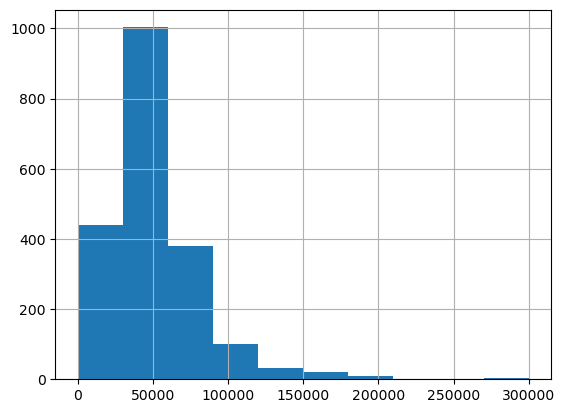

In [24]:
# зп мужчин
print(f'Медианная зп у мужчин: {clean_df[clean_df['male'] == 1]['salary'].median()}')
print(f'Средняя зп у мужчин: {round(clean_df[clean_df['male'] == 1]['salary'].mean(), 1)}')
print(clean_df[clean_df['male'] == 1]['salary'].describe())
clean_df[clean_df['male'] == 1]['salary'].hist();

Медианная зп у женщин: 30000.0
Средняя зп у женщин: 35207.0
count     2348.00
mean     35207.04
std      22104.61
min          0.00
25%      21000.00
50%      30000.00
75%      43000.00
max     300000.00
Name: salary, dtype: float64


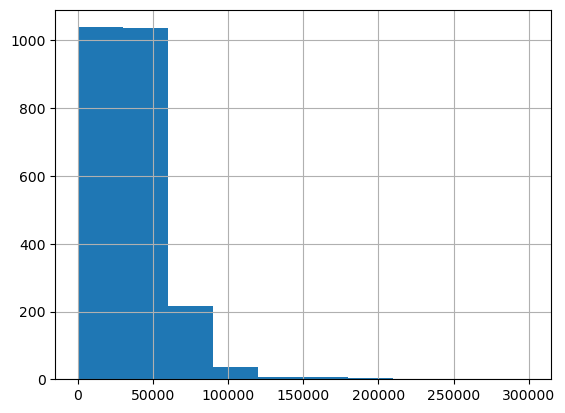

In [25]:
# средняя зп женщин
print(f'Медианная зп у женщин: {clean_df[clean_df['male'] == 2]['salary'].median()}')
print(f'Средняя зп у женщин: {round(clean_df[clean_df['male'] == 2]['salary'].mean(), 1)}')
print(clean_df[clean_df['male'] == 2]['salary'].describe())
clean_df[clean_df['male'] == 2]['salary'].hist();

In [26]:
# удалим строки с нулевой зп
clean_df = clean_df[clean_df['salary'] != 0].reset_index(drop=True)

count     4312.00
mean     41552.78
std      26668.19
min        600.00
25%      25000.00
50%      35000.00
75%      50000.00
max     300000.00
Name: salary, dtype: float64


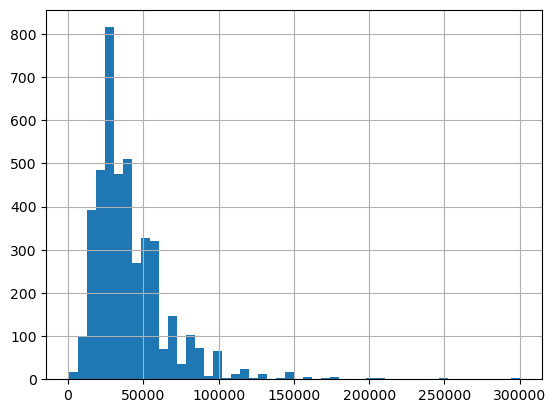

In [27]:
print(clean_df['salary'].describe())
clean_df['salary'].hist(bins=50);

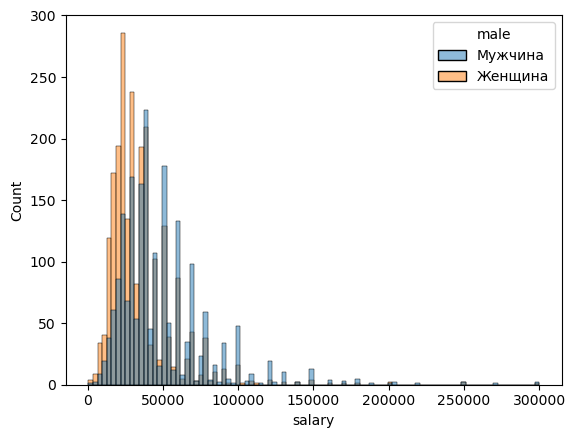

In [28]:
male_df = clean_df.copy()
male_df['male'] = male_df['male'].apply(lambda x: 'Мужчина' if x == 1 else 'Женщина')
sns.histplot(data=male_df, x='salary', hue='male', color='black')
plt.show()

In [29]:
# создадим функцию для подсчёта жестких выбросов
def emissions(df, column):
    '''Функция для подсчёта процента выбросов в столбце'''
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
   
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
 
    return f"процент выбросов составляет {round(len(df[(df[column] <= lower_bound) | (df[column] >= upper_bound)])/df.shape[0]*100, 2)}"

In [30]:
def remove_heavy_emissions(df, column):
    '''Функция для удаления выбросов через межквартильный размах'''
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
   
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
 
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].reset_index(drop=True)

In [31]:
emissions(clean_df, 'salary') 

'процент выбросов составляет 1.48'

In [32]:
clean_df['log_salary'] = np.log(clean_df['salary']) # для минсеровского уравнения возьмём логарифм зп

процент выбросов составляет 0.09
count   4312.00
mean      10.47
std        0.56
min        6.40
25%       10.13
50%       10.46
75%       10.82
max       12.61
Name: log_salary, dtype: float64


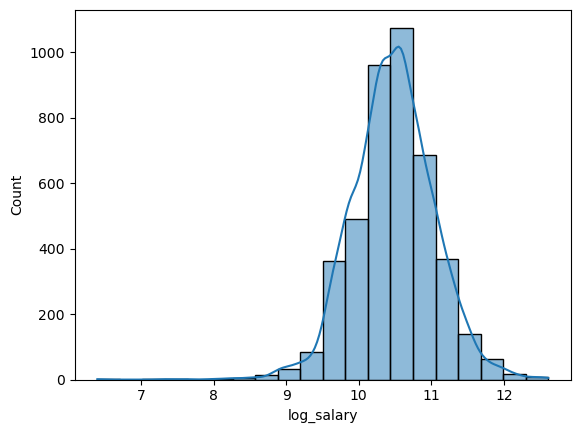

In [33]:
print(emissions(clean_df, 'log_salary'))
print(clean_df['log_salary'].describe())
sns.histplot(clean_df['log_salary'], kde=True, bins=20); # распределение 

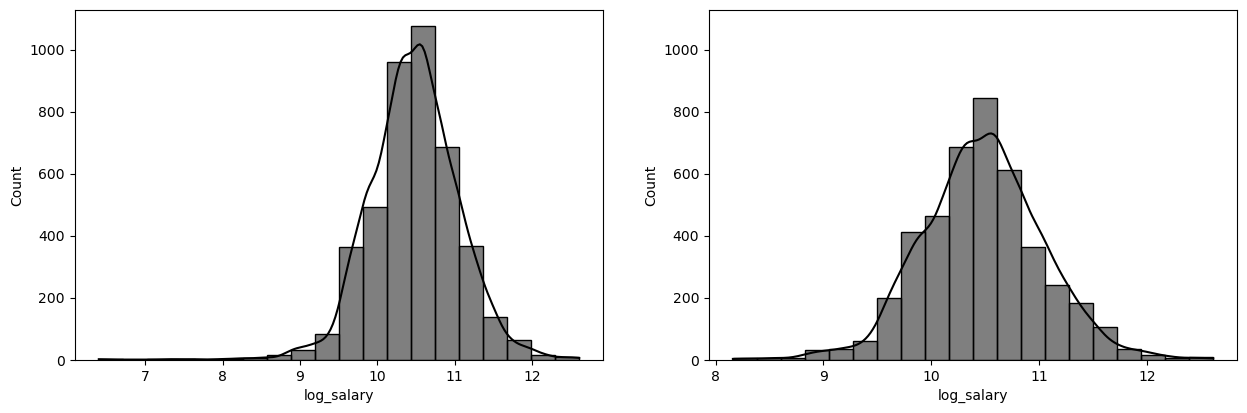

In [34]:
plt.figure(figsize=(15, 10))
ax1 = plt.subplot(2, 2, 1)
sns.histplot(clean_df['log_salary'], kde=True, bins=20, ax=ax1, color='black')
ax2 = plt.subplot(2, 2, 2, sharey = ax1)
clean_df = remove_heavy_emissions(clean_df, 'log_salary')
sns.histplot(clean_df['log_salary'], kde=True, bins=20, ax=ax2, color='black')
plt.show()

In [35]:
# Создаём копию данных и переименовываем значения
gender_df = clean_df.copy()
# Считаем количество мужчин и женщин
gender_counts = male_df['male'].value_counts()
print(gender_counts)

male
Женщина    2324
Мужчина    1988
Name: count, dtype: int64


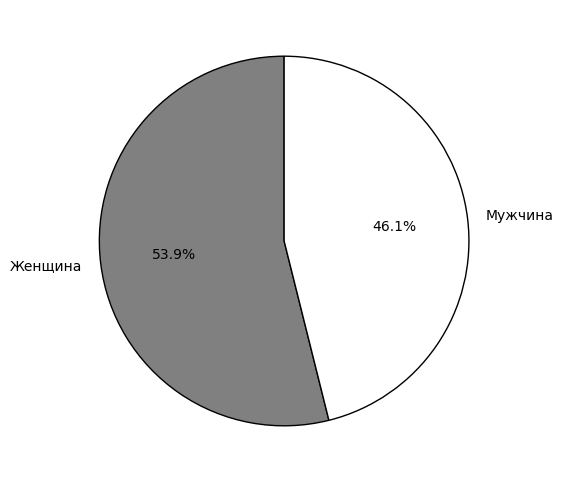

In [36]:
plt.figure(figsize=(6, 6))  # Размер графика
plt.pie(
    gender_counts,               # Данные
    labels=gender_counts.index,  # Подписи (Мужчина/Женщина)
    autopct='%.1f%%',            # Проценты с 1 десятичным знаком
    colors=['grey', 'white'], # Цвета
    startangle=90,               # Поворот на 90 градусов
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'},
    # legend = True# Границы секторов
)
# plt.title('Распределение мужчин и женщин')
plt.show()

### Предобработка

In [38]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                4308 non-null   int64  
 1   region                            4308 non-null   int64  
 2   locality                          4308 non-null   int64  
 3   marital_status                    4308 non-null   float64
 4   occupation                        4308 non-null   float64
 5   edu                               4308 non-null   float64
 6   age                               4308 non-null   float64
 7   male                              4308 non-null   int64  
 8   birthplace                        1706 non-null   float64
 9   employment                        4308 non-null   float64
 10  job_satisfaction                  4308 non-null   float64
 11  labour_conditions_satisfaction    4308 non-null   float64
 12  salary

In [39]:
def null_transform(columns, data): # создадим функцию для удаления артефактов
    for i in columns:
        for n in (99999996.00, 99999997.00, 99999999.00, 99999998.00):
            data.loc[data[i] == n, i] = np.nan

In [40]:
col = list(clean_df.columns.values)
null_transform(col, clean_df) 

In [41]:
clean_df.describe()

,id,region,locality,marital_status,occupation,edu,age,male,birthplace,employment,job_satisfaction,labour_conditions_satisfaction,salary_satisfaction,promotion_satisfaction,industry,work_schedule,organization_size,salary,hazardous_industry,state_owner,foreign_owner,self_owner,management_trust,colleagues_trust,new_job_confidence,life_satisfaction,financial_situation_satisfaction,diplom,courses,foreign_language,kids,experience,health,disability,depression,log_salary
count,4308.00,4308.00,4308.00,4300.00,4299.00,4300.00,4308.00,4308.00,1702.00,4308.00,4284.00,4288.00,4286.00,4157.00,4292.00,3949.00,2982.00,4308.00,4259.00,4189.00,4168.00,4303.00,4215.00,4239.00,4211.00,4274.00,4285.00,4307.00,4307.00,4297.00,3232.00,4032.00,4278.00,4308.00,4276.00,4308.00
mean,42162.31,17.85,2.01,2.32,4.60,4.92,44.20,1.54,1.91,1.02,2.10,2.08,2.81,2.40,10.82,42.82,451.29,41589.74,1.87,1.56,1.98,1.97,2.03,1.91,2.87,2.43,3.29,6.91,1.94,1.78,1.73,20.80,2.51,1.98,1.95,10.48
std,17286.66,11.51,1.14,1.08,2.48,1.01,12.18,0.50,0.92,0.19,0.75,0.78,1.08,0.98,5.67,10.75,2490.75,26652.95,0.34,0.50,0.14,0.16,0.81,0.68,1.18,0.89,1.06,3.42,0.24,0.42,0.82,12.26,0.59,0.14,0.22,0.56
min,93.00,1.00,1.00,1.00,0.00,1.00,16.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,4.00,1.00,3500.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,8.16
25%,30271.75,7.00,1.00,2.00,3.00,4.00,35.00,1.00,1.00,1.00,2.00,2.00,2.00,2.00,7.00,40.00,13.00,25000.00,2.00,1.00,2.00,2.00,2.00,1.00,2.00,2.00,2.00,5.00,2.00,2.00,1.00,11.00,2.00,2.00,2.00,10.13
50%,45599.00,18.00,2.00,2.00,4.00,5.00,44.00,2.00,2.00,1.00,2.00,2.00,3.00,2.00,11.00,40.00,36.00,35000.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,2.00,3.00,6.00,2.00,2.00,2.00,20.00,2.00,2.00,2.00,10.46
75%,58213.00,28.00,3.00,3.00,7.00,6.00,53.00,2.00,3.00,1.00,2.00,2.00,4.00,3.00,14.00,48.00,120.00,50000.00,2.00,2.00,2.00,2.00,2.00,2.00,4.00,3.00,4.00,10.00,2.00,2.00,2.00,30.00,3.00,2.00,2.00,10.82
max,63957.00,38.00,4.00,6.00,9.00,6.00,86.50,2.00,3.00,4.00,5.00,5.00,5.00,5.00,31.00,120.00,90000.00,300000.00,2.00,2.00,2.00,2.00,5.00,5.00,5.00,5.00,5.00,17.00,2.00,2.00,11.00,69.00,5.00,2.00,2.00,12.61


In [42]:
clean_df.isna().sum()/len(clean_df)*100 

id                                  0.00
region                              0.00
locality                            0.00
marital_status                      0.19
occupation                          0.21
edu                                 0.19
age                                 0.00
male                                0.00
birthplace                         60.49
employment                          0.00
job_satisfaction                    0.56
labour_conditions_satisfaction      0.46
salary_satisfaction                 0.51
promotion_satisfaction              3.51
industry                            0.37
work_schedule                       8.33
organization_size                  30.78
salary                              0.00
hazardous_industry                  1.14
state_owner                         2.76
foreign_owner                       3.25
self_owner                          0.12
management_trust                    2.16
colleagues_trust                    1.60
new_job_confiden

### График работы

count   3949.00
mean      42.82
std       10.75
min        4.00
25%       40.00
50%       40.00
75%       48.00
max      120.00
Name: work_schedule, dtype: float64
Пропуски: 359


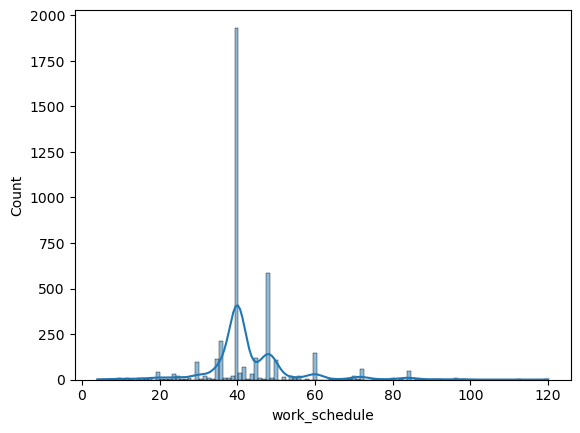

In [44]:
print(clean_df['work_schedule'].describe())
print(f'Пропуски: {clean_df['work_schedule'].isna().sum()}')
sns.histplot(clean_df['work_schedule'], kde=True);

In [45]:
print(f'Медианный график работы женщины: {clean_df[clean_df['male'] == 2]['work_schedule'].mean()} ч/нед')
print(f'Медианный график работы мужчины: {clean_df[clean_df['male'] == 1]['work_schedule'].mean()} ч/нед')

Медианный график работы женщины: 40.79734675205855 ч/нед
Медианный график работы мужчины: 45.31707317073171 ч/нед


In [46]:
gender_df = clean_df.copy()

gender_counts = male_df['male'].value_counts()
print(gender_counts)

male
Женщина    2324
Мужчина    1988
Name: count, dtype: int64


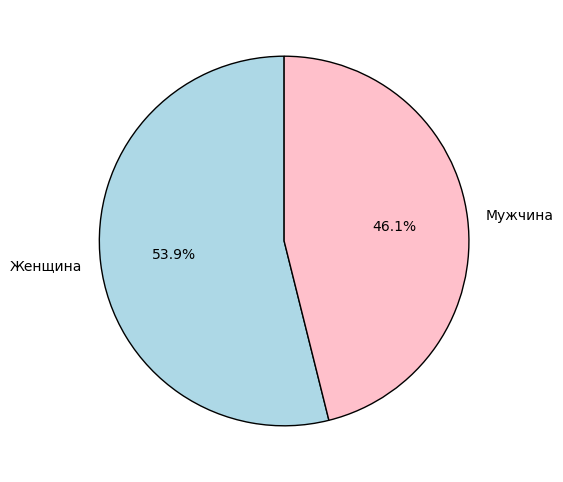

In [47]:
plt.figure(figsize=(6, 6)) 
plt.pie(
    gender_counts,               
    labels=gender_counts.index,  
    autopct='%.1f%%',            
    colors=['lightblue', 'pink'], 
    startangle=90,               
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}  
)
# plt.title('Распределение мужчин и женщин')
plt.show()

In [48]:
clean_df['work_schedule'] = clean_df['work_schedule'].fillna(clean_df['work_schedule'].median())

<Axes: xlabel='work_schedule', ylabel='Count'>

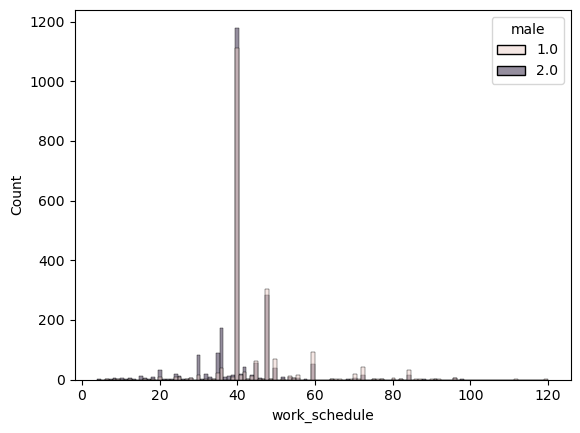

In [49]:
sns.histplot(data=clean_df, x='work_schedule', hue='male')

### Возраст

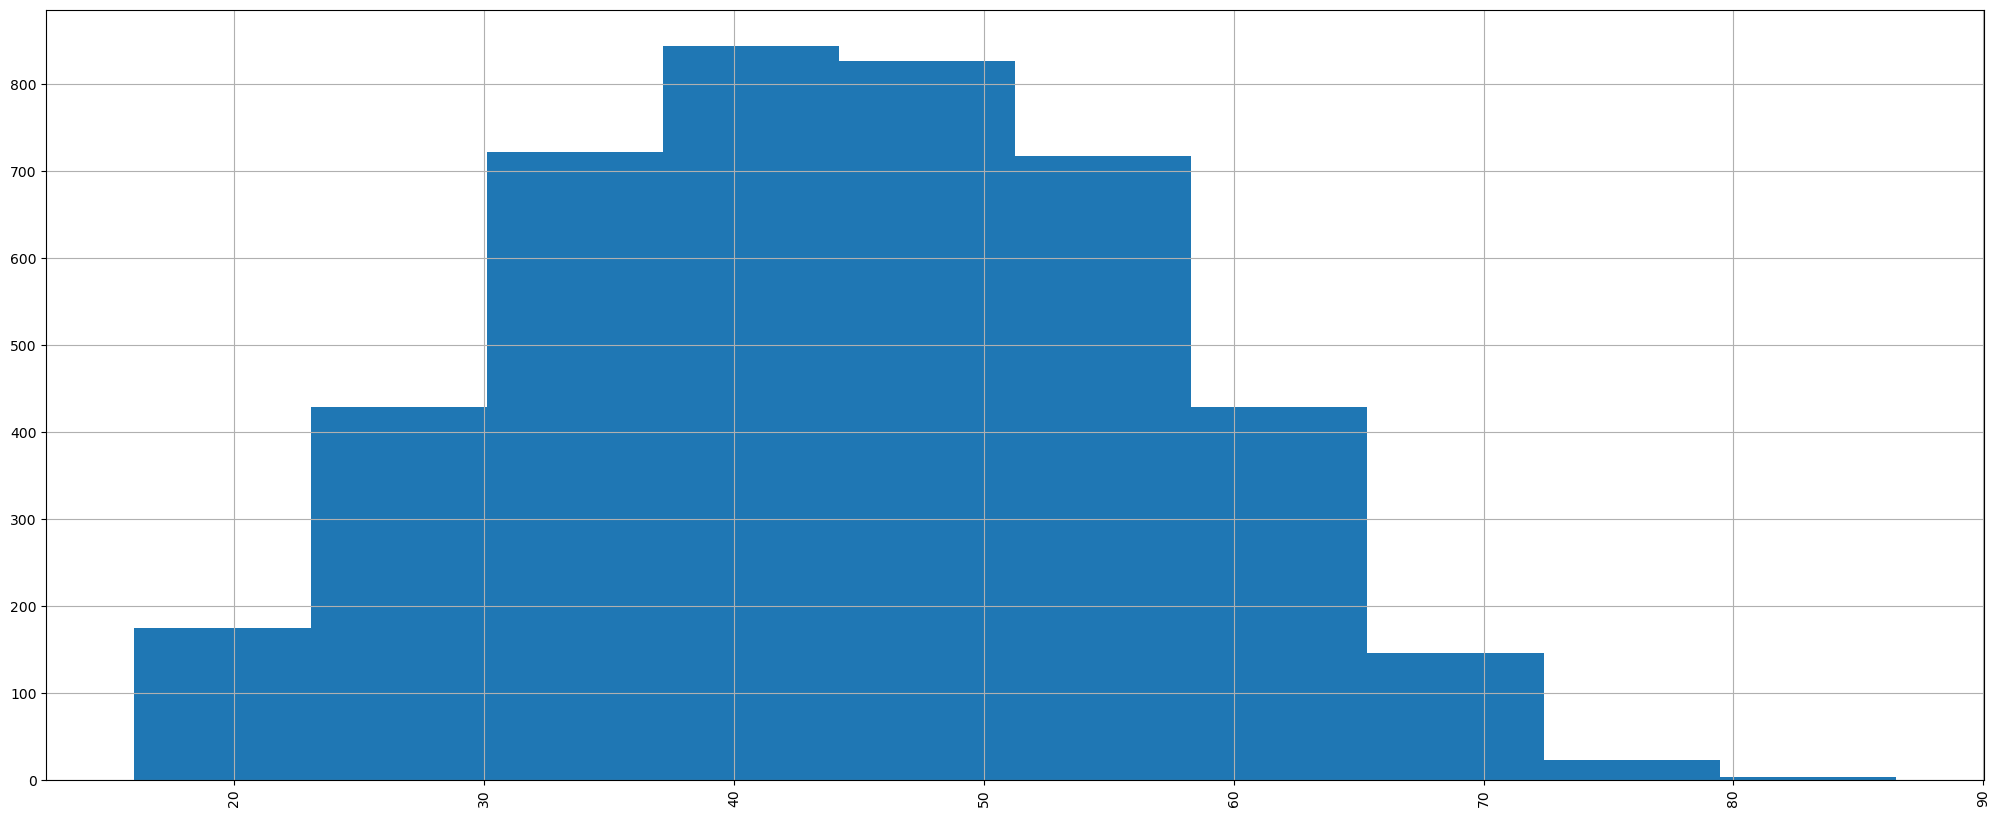

In [51]:
# возраст 
clean_df['age'].sort_values().hist(figsize=(25,10))
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='age', ylabel='Count'>

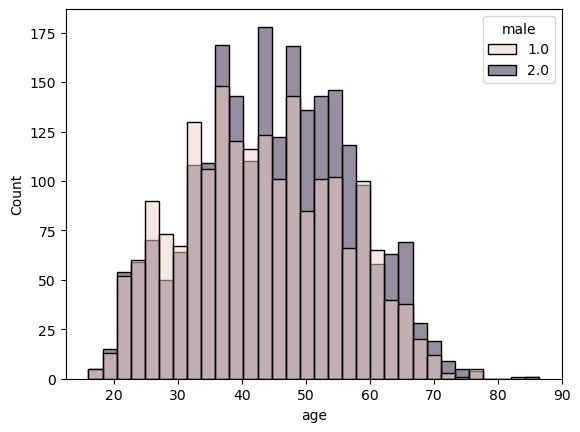

In [52]:
sns.histplot(data=clean_df, x='age', hue='male')

In [53]:
clean_df['age'].describe()

count   4308.00
mean      44.20
std       12.18
min       16.00
25%       35.00
50%       44.00
75%       53.00
max       86.50
Name: age, dtype: float64

In [54]:
emissions(clean_df, 'age')

'процент выбросов составляет 0.0'

In [55]:
clean_df['age2'] = clean_df['age']**2 # добавим квадрат возраста для дальнейшей спецификации

### Дети

In [57]:
clean_df['kids'].describe()

count   3232.00
mean       1.73
std        0.82
min        1.00
25%        1.00
50%        2.00
75%        2.00
max       11.00
Name: kids, dtype: float64

In [58]:
emissions(clean_df, 'kids')

'процент выбросов составляет 0.6'

In [59]:
clean_df['kids'].value_counts()

kids
2.00     1424
1.00     1410
3.00      320
4.00       52
5.00       12
7.00        6
6.00        6
11.00       1
9.00        1
Name: count, dtype: int64

In [60]:
# удалим из рассмотрения экстремальные значени
clean_df = clean_df[clean_df['kids'] != 11]
clean_df = clean_df[clean_df['kids'] != 9]

<Axes: >

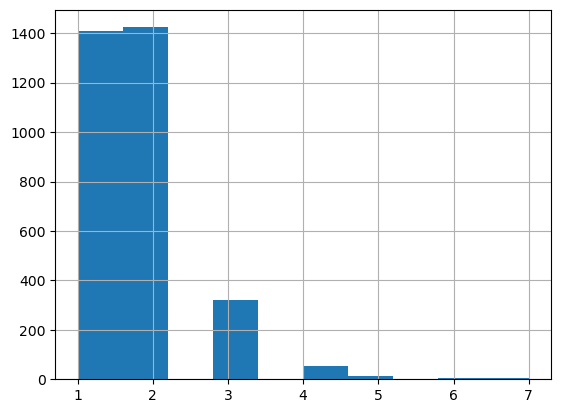

In [61]:
clean_df['kids'].hist()

<Axes: xlabel='kids', ylabel='Count'>

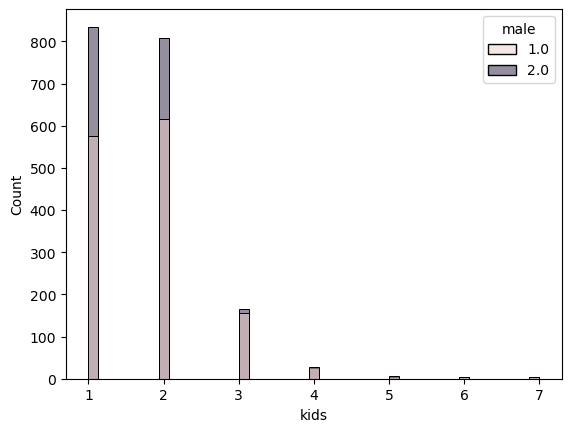

In [62]:
sns.histplot(data=clean_df, x='kids', hue='male')

In [63]:
clean_df['kids'].isna().sum()/len(clean_df)*100

24.988388295401766

In [64]:
clean_df['kids'] = clean_df['kids'].fillna(0)

### Стаж

In [66]:
clean_df['experience'].describe()

count   4030.00
mean      20.80
std       12.26
min        0.00
25%       11.00
50%       20.00
75%       30.00
max       69.00
Name: experience, dtype: float64

In [67]:
emissions(clean_df, 'experience')

'процент выбросов составляет 0.0'

<Axes: >

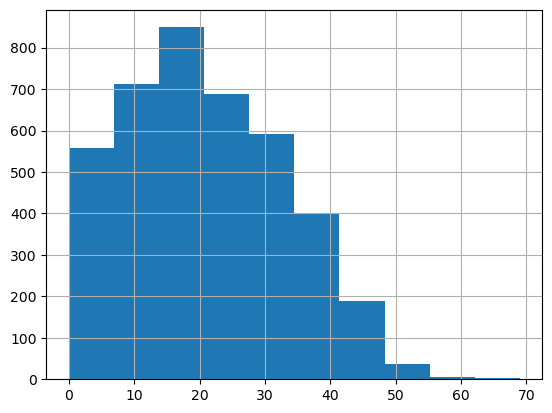

In [68]:
clean_df['experience'].hist()

In [69]:
clean_df['experience'].isna().sum()

276

In [70]:
# Создаем словарь {возраст: средний стаж} - так как есть сильная корреляция с возрастом, то заменяем пропуски на среднее для соответ-го возраста
mean_experience_by_age = clean_df.groupby('age')['experience'].mean().to_dict()
clean_df['experience'] = clean_df.apply(
    lambda row: mean_experience_by_age.get(row['age'], row['experience']) 
    if pd.isna(row['experience']) 
    else row['experience'],
    axis=1
)

In [71]:
clean_df['experience'].isna().sum() # посчитаем кол-во пропусков

5

In [72]:
clean_df['experience'] = clean_df['experience'].fillna(clean_df['experience'].median()) 

In [73]:
clean_df['experience^2'] = clean_df['experience']**2

### Размер организации

<Axes: >

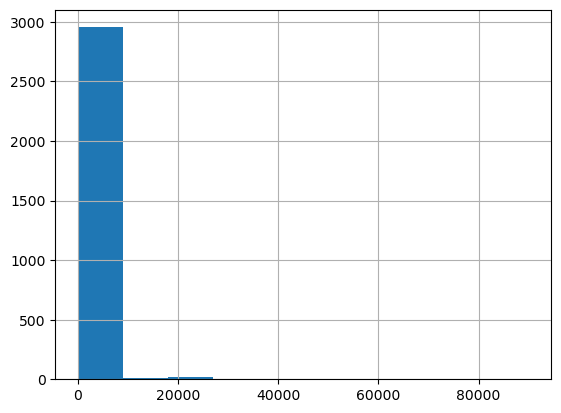

In [75]:
clean_df['organization_size'].hist()

In [76]:
print(clean_df['organization_size'].describe()) # не берём переменную из-за большого кол-ва пропусков
clean_df['organization_size'].isna().sum()/len(clean_df)*100

count    2982.00
mean      451.29
std      2490.75
min         1.00
25%        13.00
50%        36.00
75%       120.00
max     90000.00
Name: organization_size, dtype: float64


30.747793776126336

### dummy-переменные

#### Регион проживания

In [79]:
clean_df.groupby('region').mean()['salary'].sort_values(ascending=False).head(5)

region
2.00    64632.02
36.00   61751.80
3.00    52353.17
5.00    49837.14
1.00    49643.18
Name: salary, dtype: float64

<Axes: >

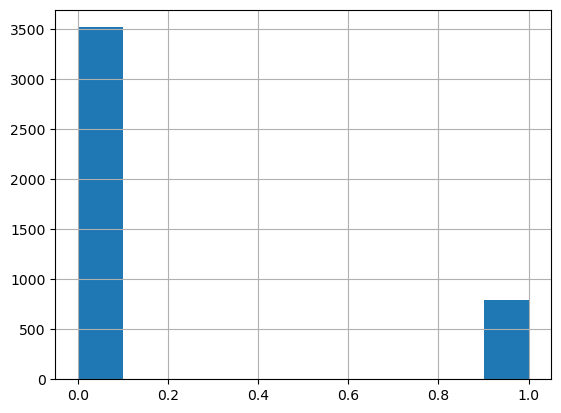

In [80]:
# разделим регион на москву, московскую область и Санкт-Петербург и остальное
clean_df['capital'] = clean_df['region'].apply(lambda x: 1 if x == 1 or x== 2 or x== 3 else 0)
clean_df['capital'].hist()

#### Место жительства

<Axes: >

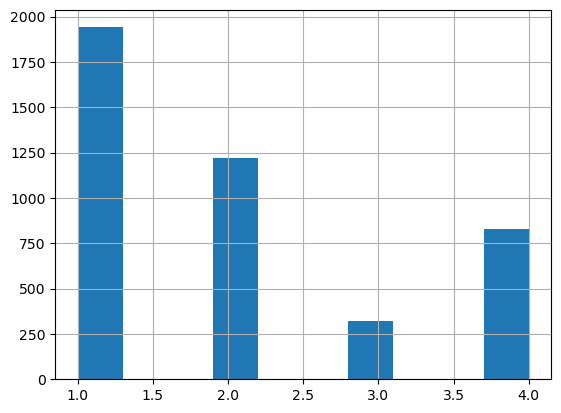

In [82]:
clean_df['locality'].hist(bins=10) # место жительства

In [83]:
# тип населённого пункта, базовая переменная - село
clean_df['city'] = clean_df['locality'].apply(lambda x: 1 if x == 1 or x== 2 else 0) # областной центр или город
clean_df['urban_type'] = clean_df['locality'].apply(lambda x: 1 if x == 3 else 0) # посёлок городского типа 

#### Семейный статус

<Axes: >

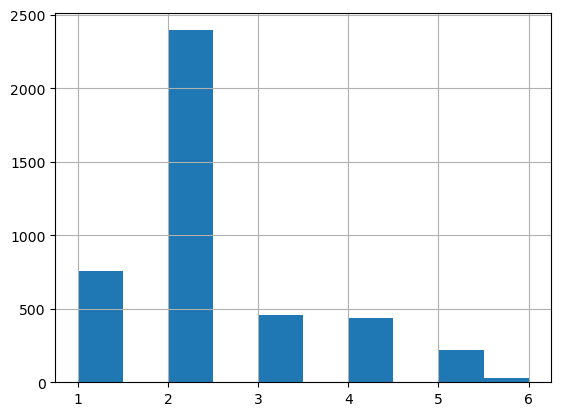

In [85]:
clean_df['marital_status'].hist() # семейный статус

In [86]:
# состояние в браке
clean_df['marital_status'] = clean_df['marital_status'].apply(lambda x: 1 if x == 2 or x == 6 else 0) 

<Axes: >

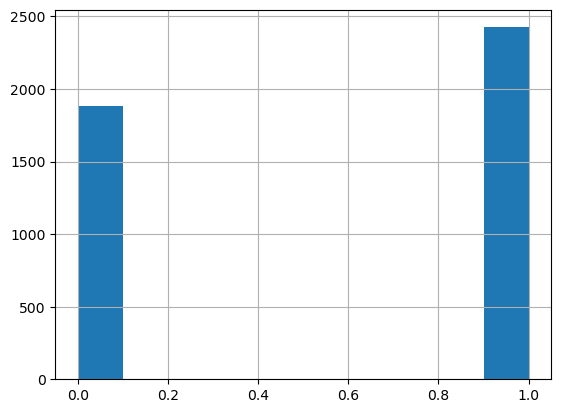

In [87]:
clean_df['marital_status'].hist()

In [88]:
clean_df['marital_status'].value_counts() # кол-во респондентов по группам

marital_status
1    2425
0    1881
Name: count, dtype: int64

#### Профессиональная группа

In [90]:
# профессиональная группа
clean_df['occupation'].value_counts()

occupation
3.00    942
2.00    766
5.00    752
7.00    503
8.00    490
9.00    330
4.00    249
1.00    236
0.00     26
6.00      3
Name: count, dtype: int64

<Axes: >

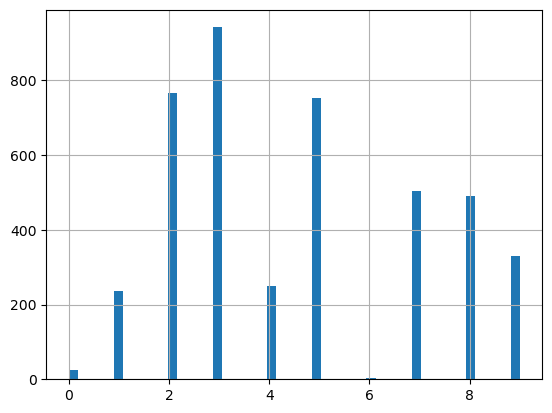

In [91]:
clean_df['occupation'].hist(bins=50)

In [92]:
print('Медианная зп')
display(clean_df.groupby('occupation').median()['salary'].sort_values(ascending=False)) # рассмотрим медианную зп по сферам
print()
print('Средняя зп')
clean_df.groupby('occupation').mean()['salary'].sort_values(ascending=False) # рассмотрим среднюю зп по сферам

Медианная зп


occupation
0.00   55000.00
1.00   50000.00
2.00   40000.00
7.00   40000.00
8.00   40000.00
3.00   37000.00
4.00   32000.00
5.00   28000.00
6.00   25000.00
9.00   24000.00
Name: salary, dtype: float64


Средняя зп


occupation
0.00   70411.54
1.00   59927.08
2.00   47547.46
8.00   47039.63
7.00   44036.88
3.00   41081.16
4.00   36390.36
5.00   31683.14
9.00   28804.25
6.00   28333.33
Name: salary, dtype: float64

Наибольшая медианная заработная плата у чиновкников и высшего/среднего руководства, а также у специалистов высшего уровня квалификации и квалифицированных рабочих ручного и масшинного труда

In [94]:
clean_df = clean_df[clean_df['occupation'] != 0].reset_index(drop=True) # убираем из выборки военнослужащих из-за другого механизма форитрования з/п

In [95]:
clean_df['occupation'].isna().sum() # проверяем пропуски

9

In [96]:
# заполним пропуски
clean_df.loc[(clean_df['occupation'].isna()) & ((clean_df['industry'] == 18) | (clean_df['industry'] == 7)| (clean_df['industry'] == 12)| (clean_df['industry'] == 13)),'occupation'] = 5
clean_df.loc[(clean_df['occupation'].isna()) & ((clean_df['industry'] == 4) | (clean_df['industry'] == 5)), 'occupation'] = 8
clean_df.loc[(clean_df['occupation'].isna()) & (clean_df['industry'] == 6), 'occupation'] = 7
clean_df = clean_df[clean_df['occupation'].isna() == False].reset_index(drop=True)

In [97]:
# разделим на управляющие позиции, база - неуправленцы
clean_df['high_qualifited'] = clean_df['occupation'].apply(lambda x: 1 if x == 1 else 0) 

In [98]:
clean_df['high_qualifited'].value_counts()

high_qualifited
0    4042
1     236
Name: count, dtype: int64

In [99]:
print(f'Доля женщин на руководящей позиции: {clean_df[clean_df['male'] == 2]['high_qualifited'].sum()/clean_df['high_qualifited'].sum()}')
print(f'Доля мужчин на руководящей позиции: {clean_df[clean_df['male'] == 1]['high_qualifited'].sum()/clean_df['high_qualifited'].sum()}')

Доля женщин на руководящей позиции: 0.4830508474576271
Доля мужчин на руководящей позиции: 0.5169491525423728


#### Уровень образования

<Axes: >

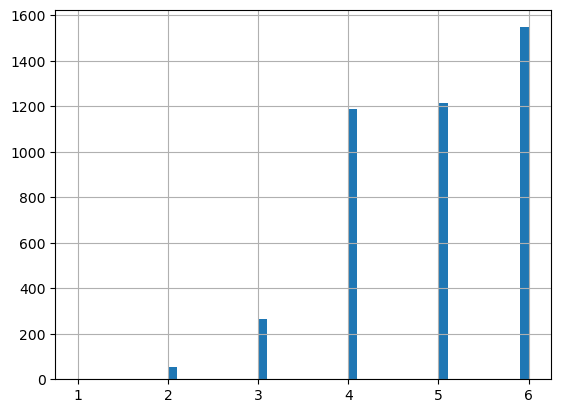

In [101]:
# законченное образование
clean_df['edu'].hist(bins=50)

In [102]:
clean_df['edu'].value_counts()

edu
6.00    1547
5.00    1214
4.00    1186
3.00     265
2.00      56
1.00       2
Name: count, dtype: int64

In [103]:
clean_df[clean_df['edu'] == 1]['salary'] # гипотеза о том, что у респондентов с неоконченным средним образованием нет зп отклонена

602    13000.00
1618   16000.00
Name: salary, dtype: float64

In [104]:
# базовая переменная - неоконченное среднее общее и ниже
clean_df['secondary_edu'] = clean_df['edu'].apply(lambda x: 1 if x == 4 else 0) # среднее общее 
clean_df['proff_edu'] = clean_df['edu'].apply(lambda x: 1 if x == 5 else 0) # среднее профессиональное
clean_df['high_edu'] = clean_df['edu'].apply(lambda x: 1 if x == 6 else 0) # высшее 

#### Место рождения

<Axes: >

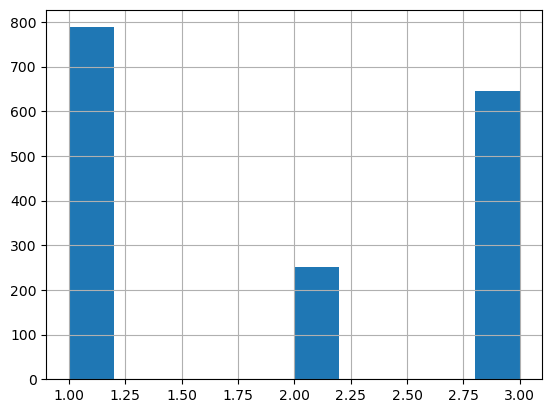

In [106]:
# место рождения 1- город, 2 - ПГТ, 3 - деревня,село
clean_df['birthplace'].hist()

In [107]:
# поставим в места пропуска тип населённого пункта, в котором живёт респондент на даный момент
clean_df.loc[((clean_df['locality'] == 1) | (clean_df['locality'] == 2)) & (clean_df['birthplace'].isna() == True), 'birthplace'] = 1
clean_df.loc[(clean_df['locality'] == 3) & (clean_df['birthplace'].isna() == True), 'birthplace'] = 2
clean_df.loc[(clean_df['locality'] == 4) & (clean_df['birthplace'].isna() == True), 'birthplace'] = 3

In [108]:
clean_df['birthplace'].value_counts() 

birthplace
1.00    2793
3.00    1063
2.00     422
Name: count, dtype: int64

#### Трудоустройство

In [110]:
# трудоустройство 1 - работает, 2 - декретный отпуск, 3 - оплачиваемый отпуск, 4 - неоплачиваемый отпуск
clean_df['employment'].value_counts()

employment
1.00    4211
2.00      49
3.00      12
4.00       6
Name: count, dtype: int64

In [111]:
# возьмём за базовую переменную тех кто работает
clean_df['maternity_leave'] = clean_df['employment'].apply(lambda x: 1 if x == 2 else 0) # декретный отпуск
clean_df['vacation'] = clean_df['employment'].apply(lambda x: 1 if x == 3 or x == 4 else 0) # отпуск

<Axes: xlabel='vacation', ylabel='Count'>

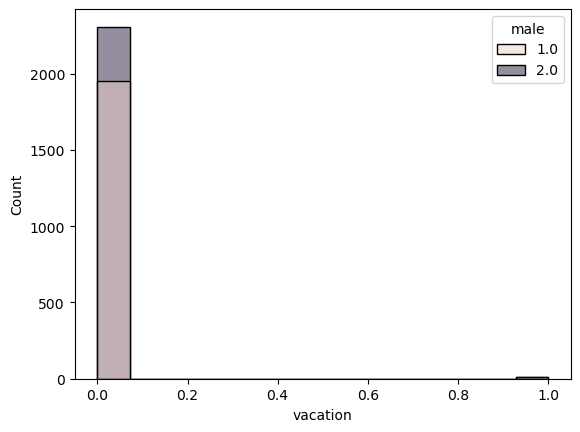

In [112]:
sns.histplot(data=clean_df, x='vacation', hue='male')

### Бинарные переменные

In [114]:
def bin(df, col): # создадим функцию для бинарных переменных
    
    df[col] = df[col].apply(lambda x: 1 if x == 1 else 0)
    display(df[col].value_counts())
    df[col].hist()

hazardous_industry
0    3726
1     552
Name: count, dtype: int64

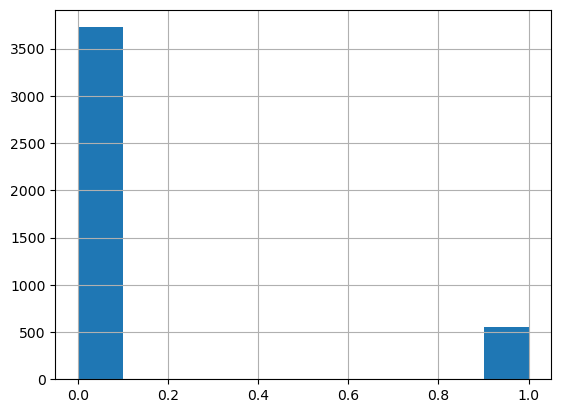

In [115]:
# вредное производство, 1 - да
bin(clean_df, 'hazardous_industry')

state_owner
0    2468
1    1810
Name: count, dtype: int64

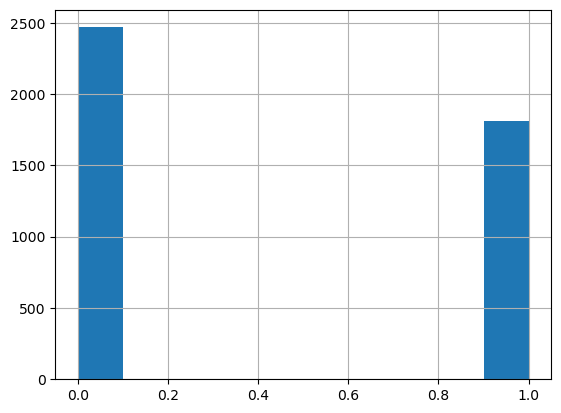

In [116]:
# государство собственник организации, 1 - да
bin(clean_df, 'state_owner')

foreign_owner
0    4200
1      78
Name: count, dtype: int64

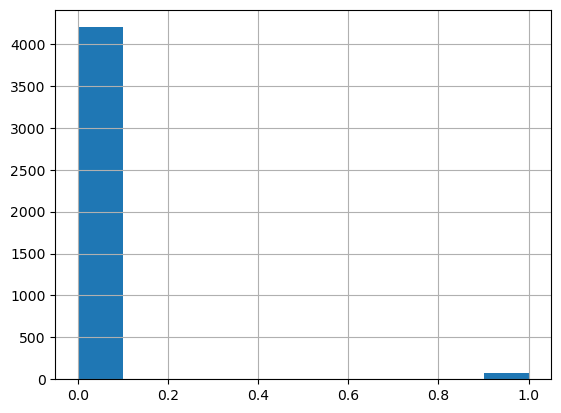

In [117]:
# иностранец собственник организации, 1 - да
bin(clean_df, 'foreign_owner')

self_owner
0    4162
1     116
Name: count, dtype: int64

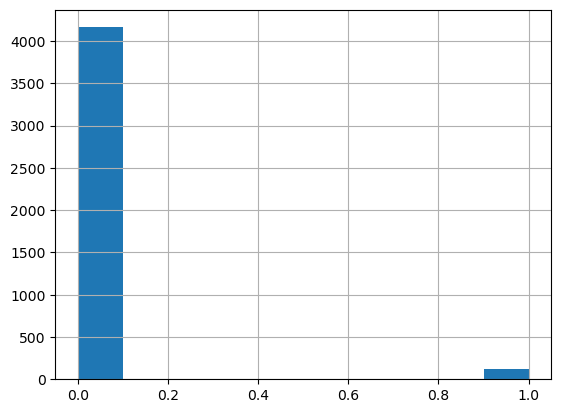

In [118]:
# собственник организации, 1 - да
bin(clean_df, 'self_owner')

In [119]:
# рассмотрим распределние профессий по управленцам
self_df = pd.DataFrame(clean_df[clean_df['self_owner'] == 1]['occupation'].value_counts()).reset_index().sort_values(by='occupation')
self_df

,occupation,count
0,1.00,40
2,2.00,15
4,3.00,11
6,4.00,4
1,5.00,25
7,6.00,1
3,7.00,13
5,8.00,6
8,9.00,1


In [120]:
self_df2 = pd.DataFrame(clean_df[clean_df['self_owner'] == 0]['occupation'].value_counts()).reset_index().sort_values(by='occupation')

self_df2

,occupation,count
7,1.00,196
1,2.00,751
0,3.00,931
6,4.00,245
2,5.00,731
8,6.00,2
3,7.00,491
4,8.00,486
5,9.00,329


depression
0    4061
1     217
Name: count, dtype: int64

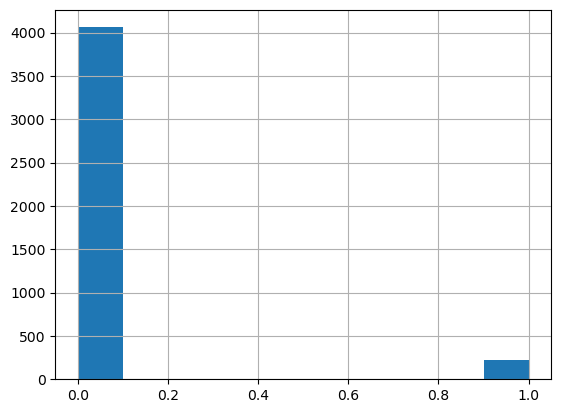

In [121]:
# наличие депрессии и нервных расстройств, 1 - да
bin(clean_df, 'depression')

disability
0    4195
1      83
Name: count, dtype: int64

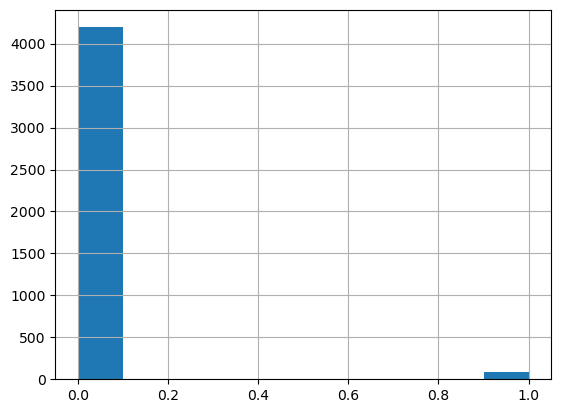

In [122]:
# наличие инвалидности, 1 - да
bin(clean_df, 'disability')

male
0    2317
1    1961
Name: count, dtype: int64

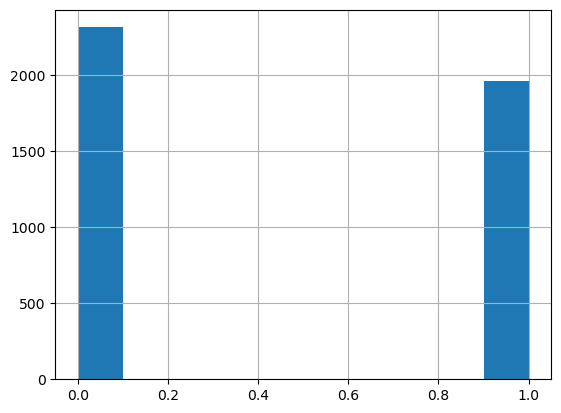

In [123]:
bin(clean_df, 'male') # 0 - мужчины, 1 - женщины

courses
0    4016
1     262
Name: count, dtype: int64

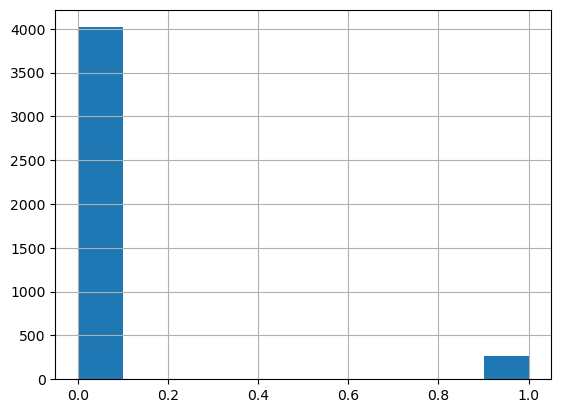

In [124]:
# прохождение профессиональных курсов
bin(clean_df, 'courses')

foreign_language
0    3326
1     952
Name: count, dtype: int64

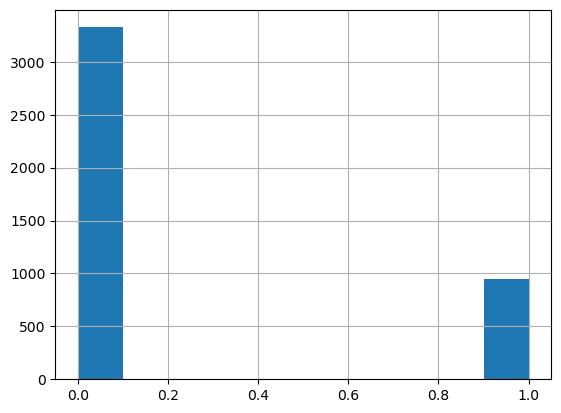

In [125]:
# знание иностранного языка
bin(clean_df, 'foreign_language')

### Удовлетворённость

In [127]:
clean_df[['job_satisfaction', 'labour_conditions_satisfaction']]

,job_satisfaction,labour_conditions_satisfaction
0,2.00,2.00
1,2.00,2.00
2,1.00,1.00
3,3.00,4.00
4,3.00,3.00
...,...,...
4273,3.00,3.00
4274,1.00,2.00
4275,2.00,2.00
4276,1.00,1.00


In [128]:
# создадим функцию для всех переменных удовлетворённости, вариант да/нет отнесён к неудовлетворён;
# 1 - удовлетворён, 0 - не удовлетворён
def satisfaction(df, col): # создадим функцию для бинарных переменных
    
    df[col] = df[col].apply(lambda x: 1 if x == 1 or x == 2 else 0)
    display(df[col].value_counts())
    display(df[col].isna().sum())
    df[col].hist()

job_satisfaction
1    3295
0     983
Name: count, dtype: int64

0

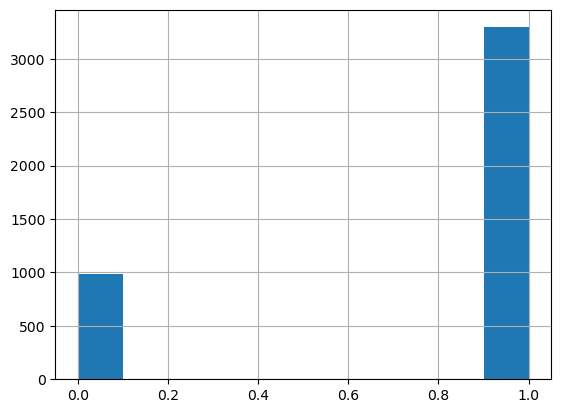

In [129]:
# удовлетворённость работой
clean_df['job_satisfaction'].value_counts()
satisfaction(clean_df, 'job_satisfaction')

labour_conditions_satisfaction
1    3323
0     955
Name: count, dtype: int64

0

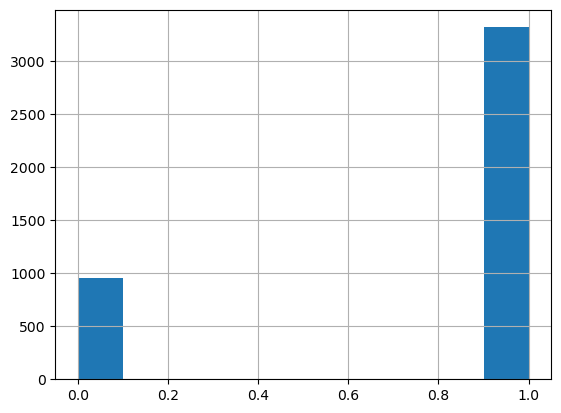

In [130]:
# удовлетворённость условиями труда
satisfaction(clean_df, 'labour_conditions_satisfaction')

salary_satisfaction
0    2443
1    1835
Name: count, dtype: int64

0

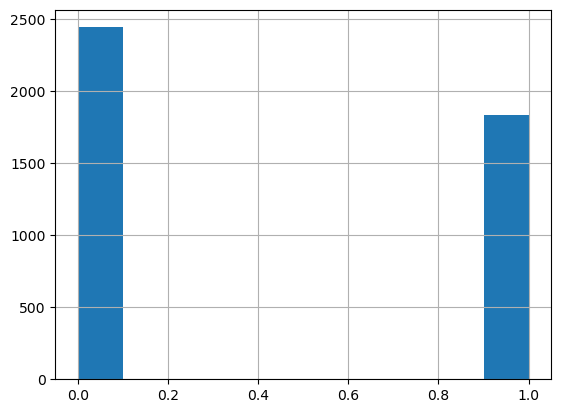

In [131]:
satisfaction(clean_df, 'salary_satisfaction') # удовлетворённость заработной платой

promotion_satisfaction
1    2642
0    1636
Name: count, dtype: int64

0

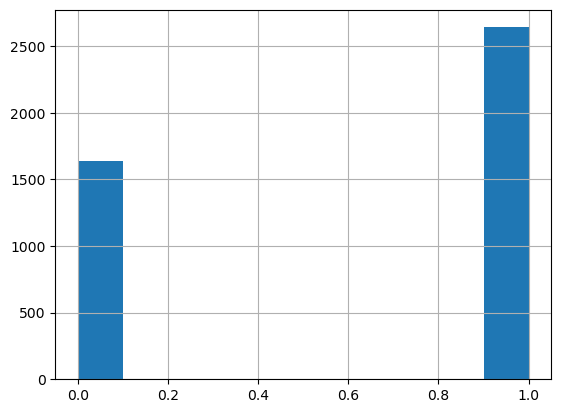

In [132]:
# возможности профессионального роста
satisfaction(clean_df, 'promotion_satisfaction')

financial_situation_satisfaction
0    3153
1    1125
Name: count, dtype: int64

0

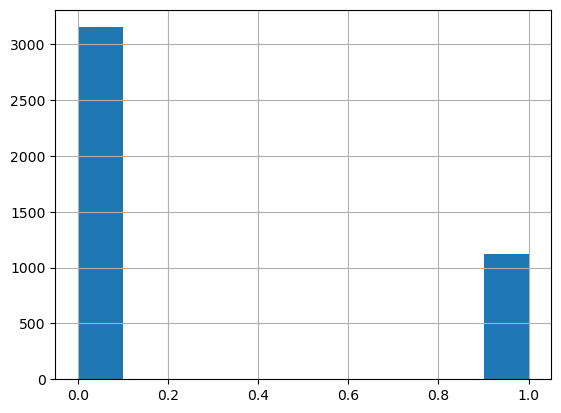

In [133]:
#  удовлетворённость финансовым состоянием
satisfaction(clean_df, 'financial_situation_satisfaction')

life_satisfaction
1    2681
0    1597
Name: count, dtype: int64

0

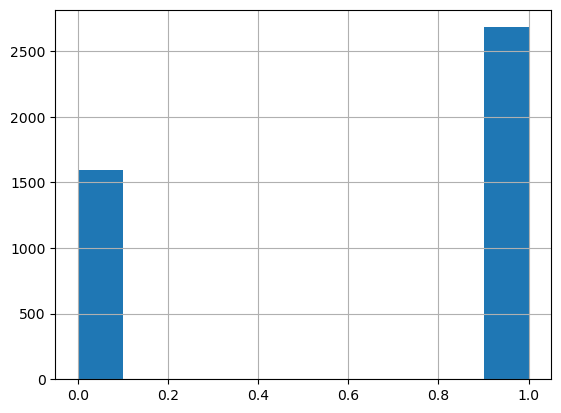

In [134]:
# удовлетворение жизнью
satisfaction(clean_df,'life_satisfaction') 

management_trust
1    3337
0     941
Name: count, dtype: int64

0

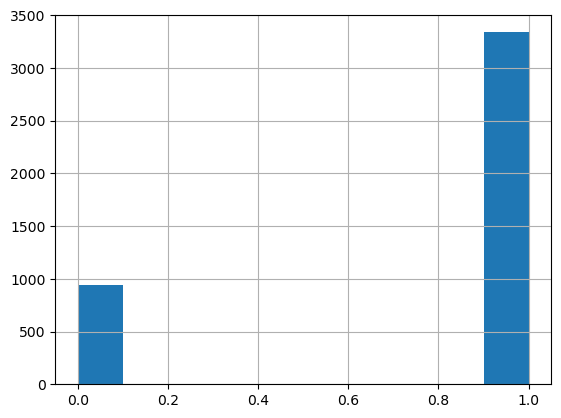

In [135]:
# доверие руководству,1 - да
satisfaction(clean_df, 'management_trust')

colleagues_trust
1    3610
0     668
Name: count, dtype: int64

0

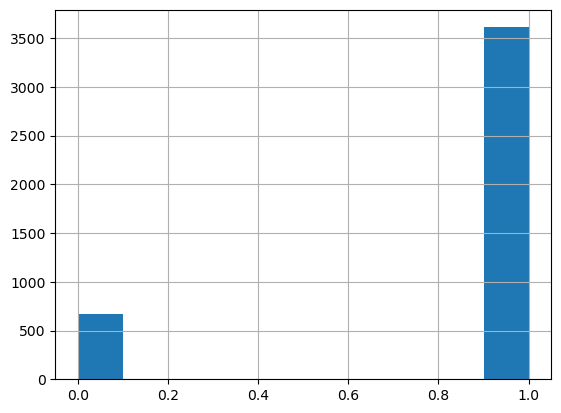

In [136]:
# доверие коллегам 
satisfaction(clean_df, 'colleagues_trust')

colleagues_trust
1    3610
0     668
Name: count, dtype: int64

0

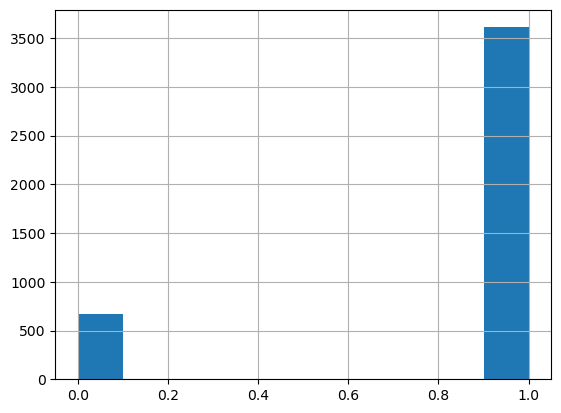

In [137]:
# уверенность в нахождении новой работы 
satisfaction(clean_df, 'colleagues_trust')

health
0    2145
1    2133
Name: count, dtype: int64

0

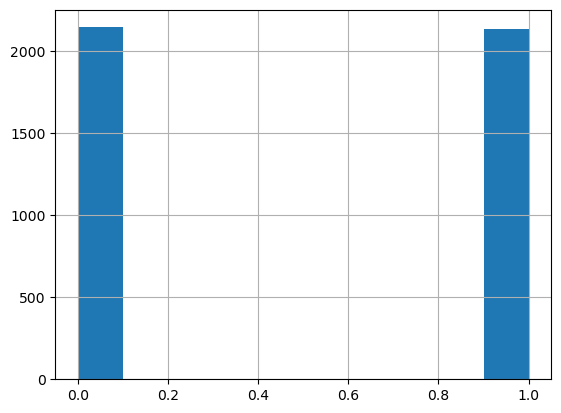

In [138]:
# уровень здоровья, 1 - хооршее
satisfaction(clean_df,'health')

new_job_confidence
0    2424
1    1854
Name: count, dtype: int64

0

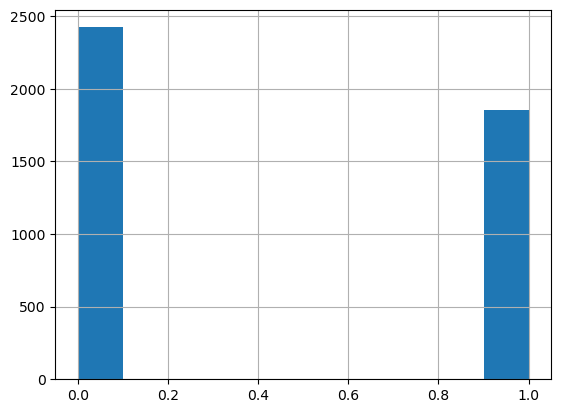

In [139]:
satisfaction(clean_df, 'new_job_confidence') # уверенность в нахождении новой работы

# Построение модели

In [141]:
df = clean_df[['male', 'age', 'age2', 'capital', 'city', 'urban_type', 'marital_status', 'secondary_edu', 'proff_edu', 'high_edu', 'high_qualifited', \
            'maternity_leave', 'vacation', 'kids', 'job_satisfaction', 'labour_conditions_satisfaction', 'salary_satisfaction', \
             'promotion_satisfaction', 'work_schedule', 'hazardous_industry', 'state_owner', 'foreign_owner', 'self_owner', 'management_trust', \
             'colleagues_trust', 'new_job_confidence', 'life_satisfaction', 'financial_situation_satisfaction', 'courses', 'foreign_language', \
            'health', 'disability', 'depression', 'experience', 'experience^2', 'log_salary']]

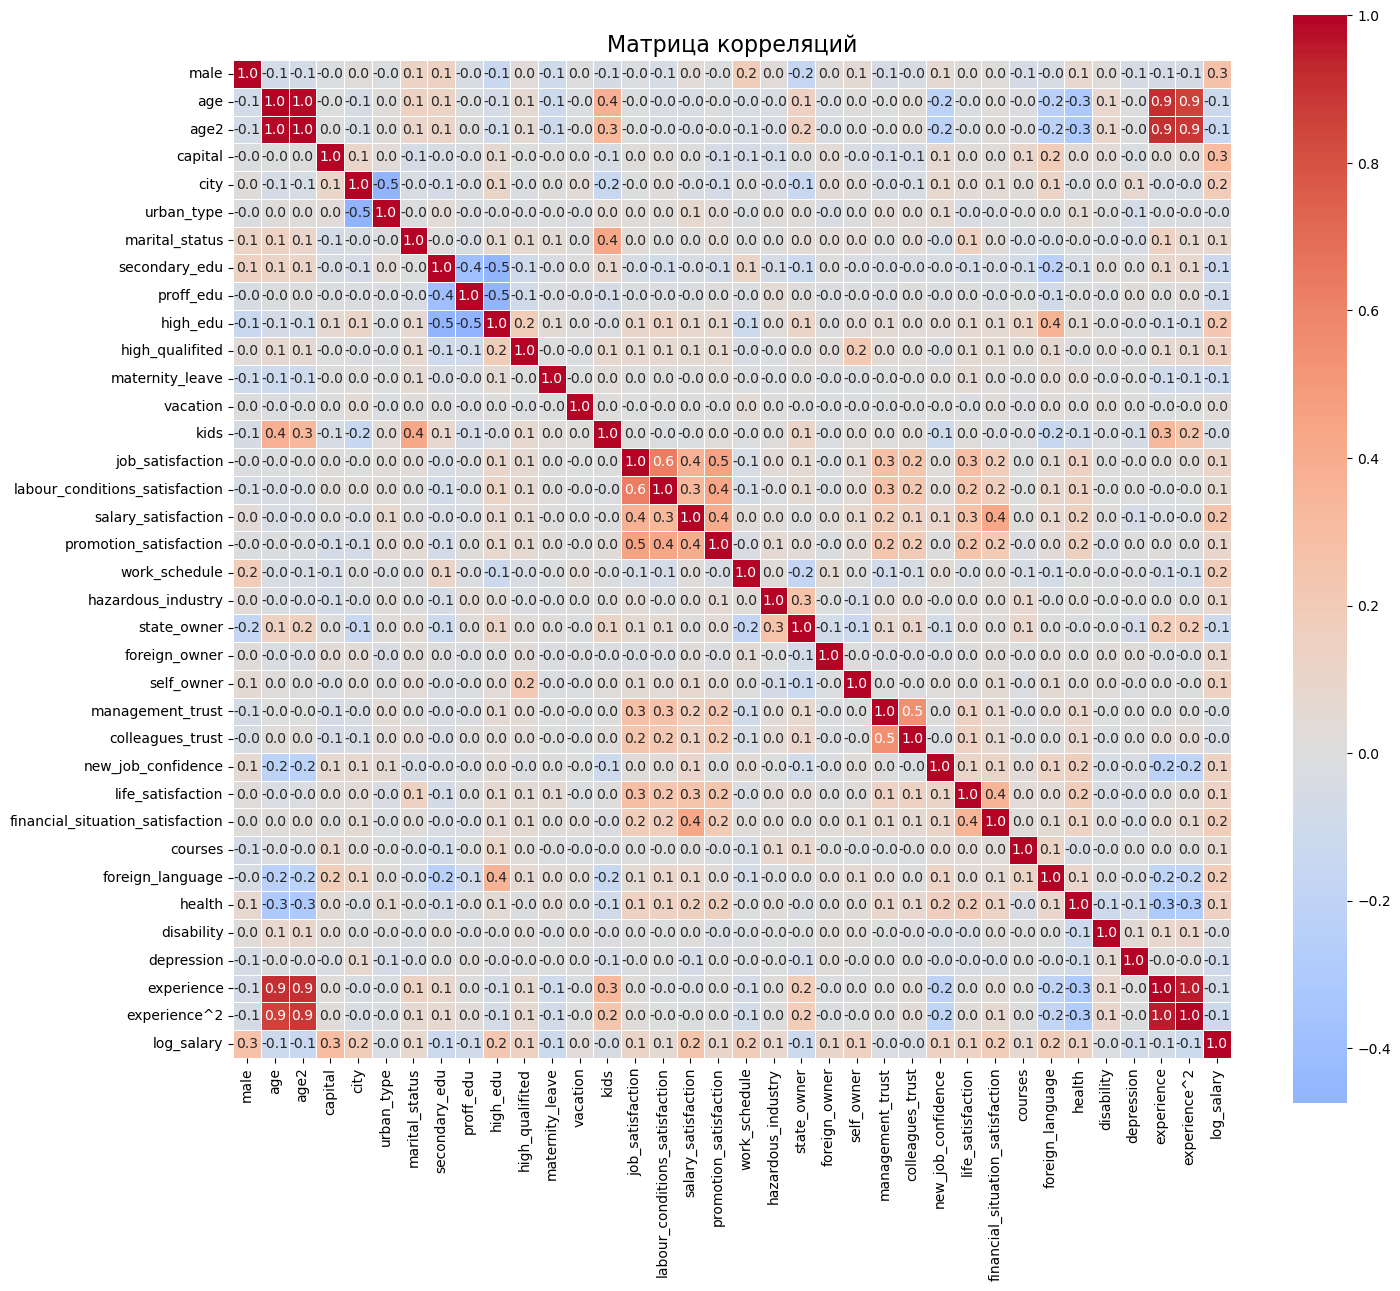

In [142]:
corr = df.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, 
            annot=True,  
            fmt='.1f',   
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

In [143]:
#выявляем признаки с высокой корреляцией
corr_matrix = np.array(df.corr().abs())
for i, j in zip(np.where(corr_matrix > 0.7)[0], np.where(corr_matrix > 0.7)[1]):
    if i != j: #не учитываем диагональ
        print(f'Признак {df.columns[i]} сильно коррелирует с признаком {df.columns[j]}')

Признак age сильно коррелирует с признаком age2
Признак age сильно коррелирует с признаком experience
Признак age сильно коррелирует с признаком experience^2
Признак age2 сильно коррелирует с признаком age
Признак age2 сильно коррелирует с признаком experience
Признак age2 сильно коррелирует с признаком experience^2
Признак experience сильно коррелирует с признаком age
Признак experience сильно коррелирует с признаком age2
Признак experience сильно коррелирует с признаком experience^2
Признак experience^2 сильно коррелирует с признаком age
Признак experience^2 сильно коррелирует с признаком age2
Признак experience^2 сильно коррелирует с признаком experience


Таким образом мультиколлениарность наблюдается у признаков age и experience - учитываем их по отдельности в разных спецификациях 

В отличие от классических корреляционных методов, которые улавливают только линейные связи, Random Forest позволяет обнаруживать сложные нелинейные и интерактивные зависимости. Кроме того, этот метод устойчив к выбросам и автоматически учитывает взаимодействия между признаками, что делает его идеальным инструментом для первичного отбора переменных в социально-экономических данных. Перейдём к оценке важности признаков с помощью Random Forest.

In [145]:
X = df.drop('log_salary', axis=1)  
y = df['log_salary']  

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

RandomForestRegressor(n_jobs=-1, random_state=42)

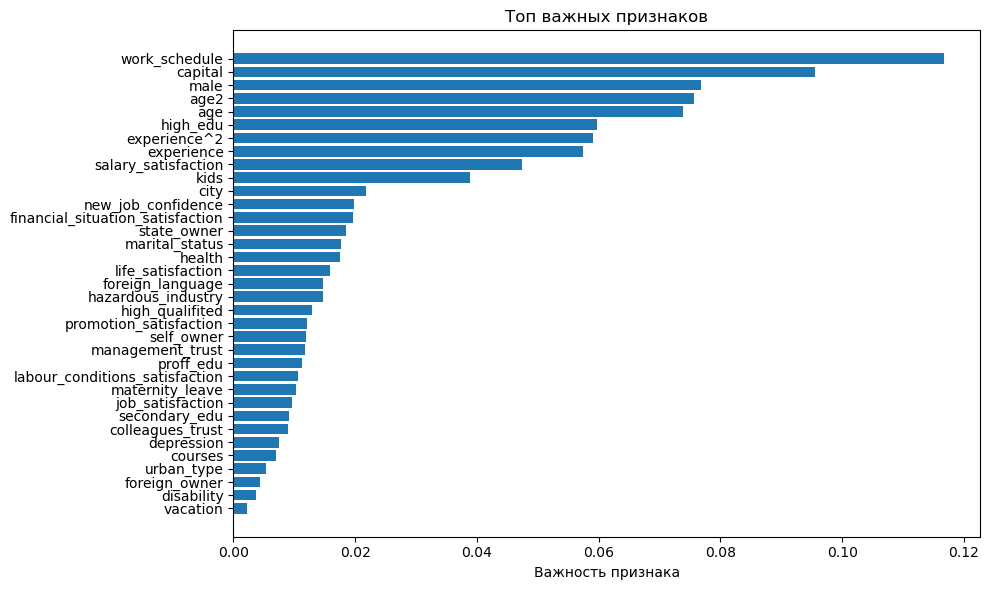

Отобрано 26 признаков:
1. work_schedule
2. capital
3. male
4. age2
5. age
6. high_edu
7. experience^2
8. experience
9. salary_satisfaction
10. kids
11. city
12. new_job_confidence
13. financial_situation_satisfaction
14. state_owner
15. marital_status
16. health
17. life_satisfaction
18. foreign_language
19. hazardous_industry
20. high_qualifited
21. promotion_satisfaction
22. self_owner
23. management_trust
24. proff_edu
25. labour_conditions_satisfaction
26. maternity_leave


In [146]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'])
plt.xlabel('Важность признака')
plt.title('Топ важных признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Выбор порога (важность > 0.01)
threshold = 0.01  # минимальная важность
selected_features = feature_importance[feature_importance['importance'] > threshold]['feature'].tolist()
# selected_features = feature_importance.head(10)['feature'].tolist()
print(f"Отобрано {len(selected_features)} признаков:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

In [147]:
df=df.drop(['job_satisfaction', 'colleagues_trust', 'depression', 'courses', 'foreign_owner', 'disability', 'vacation'], axis=1)

Таким образом, выявлены признаки для дальнейшего включения в расширенную спецификацию.

## I Спецификация

Основу эконометрического анализа в данном исследовании составляет уравнение Минсера (Mincer, 1974), разработанное Джейкобом Минсером в 1974 году, которое стало классическим инструментом для оценки влияния человеческого капитала на заработную плату. 

**Формально уравнение записывается как:**

$$
\ln(\omega_i) = \beta_0 + \beta_1 S_i + \beta_2 E_i + \beta_3 E_i^2 + \gamma X_i + \varepsilon_i
$$

**где:**

- $\ln(\omega_i)$ — натуральный логарифм заработной платы $i$-го индивида
- $S_i$ — количество лет образования
- $E_i$ — опыт работы (рассчитывается как $\text{возраст} - \text{годы образования} - 6$)
- $E_i^2$ — квадрат опыта работы (учитывает убывающую предельную отдачу от опыта)
- $X_i$ — вектор контрольных переменных (пол, регион, отрасль и др.)
- $\varepsilon_i$ — случайная ошибка

In [151]:
rdf = df.copy() 

In [152]:
r_ols1 = sm.OLS(
    endog=rdf['log_salary'],
    exog=sm.add_constant( 
        rdf[['male', 'age', 'age2', 'high_qualifited', 'work_schedule']])
).fit()
# r_ols1.summary()

**Гетероскедастичность**

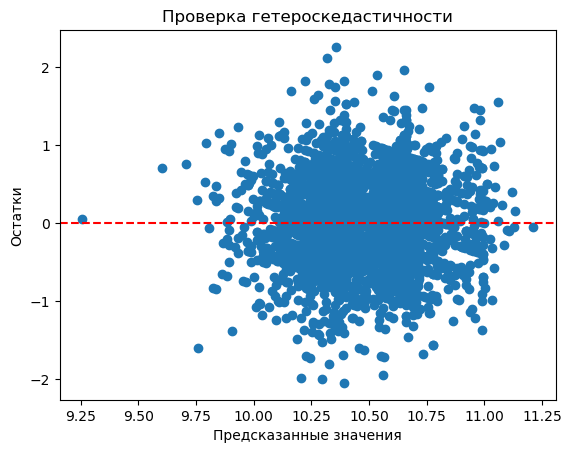

In [154]:
fitted = r_ols1.fittedvalues
residuals = r_ols1.resid

plt.scatter(fitted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Проверка гетероскедастичности")
plt.show()

In [155]:
# выполняем тест Бреуша-Пэгана
bptest = smd.het_breuschpagan(resid=r_ols1.resid, exog_het=sm.add_constant(rdf[['male', 'age', 'age2', 'high_qualifited', 'work_schedule']]))
print("\nТест Бреуша-Пагана на гетероскедастичность")
print(f"LM-статистика: {bptest[0]:.4f}")
print(f"p-value: {bptest[1]:.4f}")
print(f"F-статистика: {bptest[2]:.4f}")
print(f"F p-value: {bptest[3]:.4f}")

if bptest[1] < 0.05:
    print("\nВывод: Присутствует гетероскедастичность (p-value < 0.05).")
else:
    print("\nВывод: Гетероскедастичность не обнаружена (p-value >= 0.05).")
    print("Можно использовать стандартные ошибки OLS.")


Тест Бреуша-Пагана на гетероскедастичность
LM-статистика: 44.0976
p-value: 0.0000
F-статистика: 8.8989
F p-value: 0.0000

Вывод: Присутствует гетероскедастичность (p-value < 0.05).


Так как присутствует гетероскедастичность, то применим робастные стандартные ошибки (Huber-White)
Исправляют оценки стандартных ошибок без изменения коэффициентов

In [157]:
r_ols1 = sm.OLS(
    endog=rdf['log_salary'],
    exog=sm.add_constant( 
        rdf[['male', 'age', 'age2', 'high_qualifited', 'work_schedule']])
).fit(cov_type='HC3')
r_ols1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     125.7
Date:                Mon, 08 Dec 2025   Prob (F-statistic):          1.74e-124
Time:                        20:36:46   Log-Likelihood:                -3227.2
No. Observations:                4278   AIC:                             6466.
Df Residuals:                    4272   BIC:                             6505.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.4007      0.098     96.124      0.000       9.209       9.592
male                0.2619      0.016     16.287      0.000       0.230       0.293
age                 0.0368      0.004      8.676      0.000       0.028       0.045
age2               -0.0005   4.82e-05     -9.700      0.000      -0.001      -0.000
high_qualifited     0.3330      0.041      8.161      0.000       0.253       0.413
work_schedule       0.0069      0.001      7.468      0.000       0.005       0.009
==============================================================================
Omnibus:                       40.838   Durbin-Watson:                   1.382
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               65.209
Skew:                           0.042   Prob(JB):                     6.92e-15
Kurtosis:                       3.599   Cond. No.                     2.81e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 2.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [158]:
residuals.mean()

2.327663593012636e-12

**Тест Рамсея** (RESET-тест) выявляет ошибки спецификации модели линейной регрессии. 

Некоторые из таких ошибок:

- Наличие пропущенных переменных. Регрессия содержит не все объясняющие переменные.
- Неверная функциональная форма. Некоторые или все переменные нужно преобразовать с помощью логарифмической, степенной, обратной или другой функции. 
- Корреляция между фактором Х и случайной составляющей модели. Она может быть вызвана ошибками измерения факторов, рассмотрением систем уравнений или другими причинами.  

In [160]:
resettest = smd.linear_reset(res=r_ols1, power=2, test_type="fitted", use_f=True)
print(resettest)
if resettest.pvalue < 0.05:
        print("Отклоняем нулевую гипотезу. Модель страдает от пропущенной нелинейности")
else:
        print("Не отклоняем нулевую гипотезу. Модель линейно адекватна")

<F test: F=1.4320477921950348, p=0.23149694979531826, df_denom=4.27e+03, df_num=1>
Не отклоняем нулевую гипотезу. Модель линейно адекватна


**Мультиколлениарность**
Интерпретация: VIF > 10 — критическая мультиколлинеарность.

In [162]:
X = rdf[['male', 'age', 'age2', 'high_qualifited', 'work_schedule']]
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(f"VIF: {dict(zip(X.columns, vif))}")

VIF: {'male': 1.9235545747354654, 'age': 92.88205570834948, 'age2': 44.035730056411104, 'high_qualifited': 1.0662688637325446, 'work_schedule': 17.227988780017952}


## II Спецификация

Построим типичное уравнение Минсера через стаж

In [165]:
r_ols2 = sm.OLS( 
    endog=rdf['log_salary'],
    exog=sm.add_constant( 
        rdf[['male', 'experience', 'experience^2', 'high_qualifited', 'work_schedule']])
).fit()

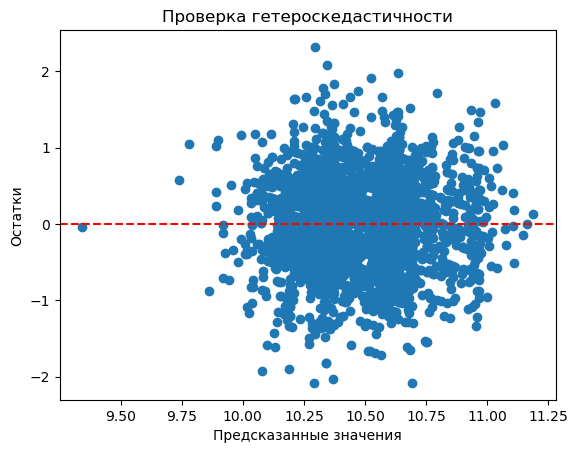

In [166]:
fitted = r_ols2.fittedvalues
residuals = r_ols2.resid

plt.scatter(fitted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Проверка гетероскедастичности")
plt.show()

In [167]:
bptest = smd.het_breuschpagan(resid=r_ols2.resid, exog_het=sm.add_constant(rdf[['male', 'experience', 'experience^2', 'high_qualifited', 'work_schedule']]))
print("\nТест Бреуша-Пагана на гетероскедастичность")
print(f"LM-статистика: {bptest[0]:.4f}")
print(f"p-value: {bptest[1]:.4f}")
print(f"F-статистика: {bptest[2]:.4f}")
print(f"F p-value: {bptest[3]:.4f}")


if bptest[1] < 0.05:
    print("\nВывод: Присутствует гетероскедастичность (p-value < 0.05).")
else:
    print("\nВывод: Гетероскедастичность не обнаружена (p-value >= 0.05).")
    print("Можно использовать стандартные ошибки OLS.")


Тест Бреуша-Пагана на гетероскедастичность
LM-статистика: 34.2356
p-value: 0.0000
F-статистика: 6.8927
F p-value: 0.0000

Вывод: Присутствует гетероскедастичность (p-value < 0.05).


Так как присутствует гетероскедастичность, то применим робастные стандартные ошибки (Huber-White)
Исправляют оценки стандартных ошибок без изменения коэффициентов

In [169]:
r_ols2 = sm.OLS( 
    endog=rdf['log_salary'],
    exog=sm.add_constant( 
        rdf[['male', 'experience', 'experience^2', 'high_qualifited', 'work_schedule']])
).fit(cov_type='HC3')
r_ols2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     110.2
Date:                Mon, 08 Dec 2025   Prob (F-statistic):          7.98e-110
Time:                        20:36:47   Log-Likelihood:                -3266.9
No. Observations:                4278   AIC:                             6546.
Df Residuals:                    4272   BIC:                             6584.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.9657      0.047    212.825      0.000       9.874      10.057
male                0.2645      0.016     16.269      0.000       0.233       0.296
experience          0.0137      0.002      6.240      0.000       0.009       0.018
experience^2       -0.0004   4.77e-05     -7.696      0.000      -0.000      -0.000
high_qualifited     0.3315      0.041      8.097      0.000       0.251       0.412
work_schedule       0.0070      0.001      7.421      0.000       0.005       0.009
==============================================================================
Omnibus:                       42.232   Durbin-Watson:                   1.398
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.360
Skew:                           0.014   Prob(JB):                     8.68e-16
Kurtosis:                       3.623   Cond. No.                     4.10e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 4.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [170]:
resettest = smd.linear_reset(res=r_ols2, power=2, test_type="fitted", use_f=True)
print(resettest)
if resettest.pvalue < 0.05:
        print("Отклоняем нулевую гипотезу. Модель страдает от пропущенной нелинейности")
else:
        print("Не отклоняем нулевую гипотезу. Модель линейно адекватна")

<F test: F=0.01167332905689034, p=0.9139665138829046, df_denom=4.27e+03, df_num=1>
Не отклоняем нулевую гипотезу. Модель линейно адекватна


In [171]:
X = rdf[['male', 'experience', 'experience^2', 'high_qualifited', 'work_schedule']]
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(f"VIF: {dict(zip(X.columns, vif))}")

VIF: {'male': 1.9197907366070366, 'experience': 34.6933283637381, 'experience^2': 19.799456349219945, 'high_qualifited': 1.066106000471475, 'work_schedule': 6.910281693665694}


In [172]:
rdf=rdf.drop(['experience', 'experience^2'], axis=1)

## Расширенная спецификация

Включение расширенного набора переменных в Минсеровское уравнение обусловлено необходимостью учета многомерных факторов, влияющих на заработную плату, и минимизации смещения оценок гендерного разрыва. Классические переменные - образование, опыт и пол - дополняются социально-демографическими, институциональными и психологическими характеристиками, что позволяет изолировать «чистый» эффект гендера от перекрывающихся факторов.

Субъективные факторы (удовлетворенность зарплатой, доверие к руководству) отражают косвенные механизмы неравенства. Здоровье и человеческий капитал (курсы, иностранный язык, диплом) вводятся для учета различий в инвестициях в навыки.

In [175]:
r_ols4 = sm.OLS( 
    endog=rdf['log_salary'],
    exog=sm.add_constant( 
        rdf.drop('log_salary', axis=1))
).fit()

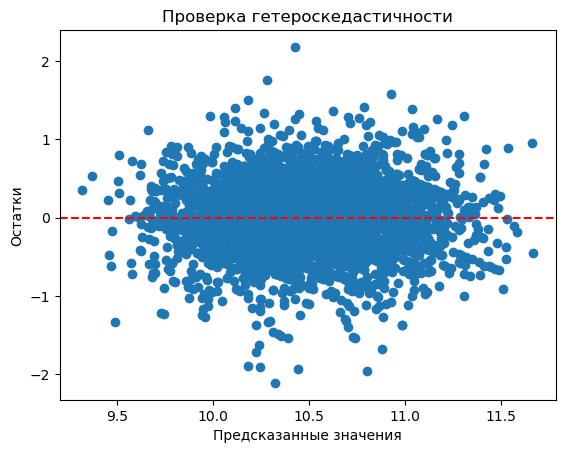

In [176]:
fitted = r_ols4.fittedvalues
residuals = r_ols4.resid

plt.scatter(fitted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Проверка гетероскедастичности")
plt.show()

Так как присутствует гетероскедастичность, то применим робастные стандартные ошибки (Huber-White)
Исправляют оценки стандартных ошибок без изменения коэффициентов

In [178]:
r_ols4 = sm.OLS( 
    endog=rdf['log_salary'],
    exog=sm.add_constant( 
        rdf.drop('log_salary', axis=1))
).fit(cov_type='HC3')
r_ols4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     108.6
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:36:47   Log-Likelihood:                -2435.1
No. Observations:                4278   AIC:                             4924.
Df Residuals:                    4251   BIC:                             5096.
Df Model:                          26                                         
Covariance Type:                  HC3                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                8.7096      0.101     86.111      0.000       8.511       8.908
male                                 0.2589      0.014     18.416      0.000       0.231       0.286
age                                  0.0420      0.004     10.670      0.000       0.034       0.050
age2                                -0.0005   4.35e-05    -11.538      0.000      -0.001      -0.000
capital                              0.4351      0.017     25.266      0.000       0.401       0.469
city                                 0.1740      0.017     10.030      0.000       0.140       0.208
urban_type                           0.0516      0.027      1.910      0.056      -0.001       0.105
marital_status                       0.0247      0.015      1.608      0.108      -0.005       0.055
secondary_edu                        0.0346      0.028      1.233      0.218      -0.020       0.090
proff_edu                            0.1072      0.028      3.763      0.000       0.051       0.163
high_edu                             0.2953      0.029     10.013      0.000       0.238       0.353
high_qualifited                      0.1702      0.035      4.883      0.000       0.102       0.239
maternity_leave                     -0.5274      0.092     -5.706      0.000      -0.709      -0.346
kids                                 0.0053      0.008      0.669      0.503      -0.010       0.021
labour_conditions_satisfaction      -0.0594      0.018     -3.353      0.001      -0.094      -0.025
salary_satisfaction                  0.1889      0.016     11.848      0.000       0.158       0.220
promotion_satisfaction               0.0291      0.016      1.839      0.066      -0.002       0.060
work_schedule                        0.0084      0.001     10.066      0.000       0.007       0.010
hazardous_industry                   0.1496      0.020      7.527      0.000       0.111       0.189
state_owner                         -0.0589      0.015     -3.937      0.000      -0.088      -0.030
self_owner                           0.2552      0.050      5.085      0.000       0.157       0.354
management_trust                    -0.0381      0.016     -2.317      0.020      -0.070      -0.006
new_job_confidence                   0.0162      0.014      1.150      0.250      -0.011       0.044
life_satisfaction                    0.0312      0.015      2.060      0.039       0.002       0.061
financial_situation_satisfaction     0.1038      0.018      5.722      0.000       0.068       0.139
foreign_language                     0.0374      0.019      1.932      0.053      -0.001       0.075
health                               0.0351      0.014      2.466      0.014       0.007       0.063
=====================================================

In [179]:
resettest = smd.linear_reset(res=r_ols4, power=2, test_type="fitted", use_f=True)
print(resettest)
if resettest.pvalue < 0.05:
        print("Отклоняем нулевую гипотезу. Модель страдает от пропущенной нелинейности")
else:
        print("Не отклоняем нулевую гипотезу. Модель линейно адекватна")

<F test: F=1.0480859018155826, p=0.30600660006171604, df_denom=4.25e+03, df_num=1>
Не отклоняем нулевую гипотезу. Модель линейно адекватна


In [180]:
X = rdf.drop('log_salary', axis=1)
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(f"VIF: {dict(zip(X.columns, vif))}")

VIF: {'male': 2.121179081845815, 'age': 191.32982382006483, 'age2': 74.2275078230089, 'capital': 1.3289616393473083, 'city': 5.275289541156069, 'urban_type': 1.442059999059983, 'marital_status': 3.020953889730442, 'secondary_edu': 4.468184828915933, 'proff_edu': 4.4948766204978226, 'high_edu': 6.141657274071986, 'high_qualifited': 1.1738921659698072, 'maternity_leave': 1.0475754708502516, 'kids': 3.869115847385341, 'labour_conditions_satisfaction': 6.064883866428482, 'salary_satisfaction': 2.594417520184657, 'promotion_satisfaction': 3.7079172299038285, 'work_schedule': 17.9984598316748, 'hazardous_industry': 1.2685421115456894, 'state_owner': 2.114381638572947, 'self_owner': 1.1133710385389994, 'management_trust': 5.046618435343642, 'new_job_confidence': 1.9626540283857465, 'life_satisfaction': 3.4137188396961045, 'financial_situation_satisfaction': 1.8371632009613303, 'foreign_language': 1.6478778023586607, 'health': 2.367668400834795}


Интерпретация: VIF > 10 — критическая мультиколлинеарность.

Таким образом, Заработная плата мужчин превышает женскую на 25.9% даже после контроля субъективных и психологических факторов.
Субъективные факторы показали, что удовлетворенность зарплатой (salary_satisfaction) увеличивает доход на 18.9% (p-value < 0.001), что отражает связь между восприятием справедливости и реальными заработками.

Проживание в столичном регионе (capital) ассоциировано с увеличением зарплаты на 43.5% (p-value < 0.001), а высшее образование (high_edu) повышает зарплату на 29.5% (p-value < 0.001), что подчеркивает роль человеческого капитала. Переменная maternity_leave значимо снижает зарплату (-52.7%, p-value < 0.001), что может отражать дисконт за перерывы в карьере.

## Перекрёстные переменные

Взаимодействие пола с другими переменными, позволяющее оценить, как эффект этих переменных на зарплату различается между мужчинами и женщинами. Например, влияние наличия детей на зарплату может быть разным для мужчин и женщин.

Включение перекрёстных переменных в модель позволяет исследовать гетерогенность влияния социально-демографических и профессиональных факторов на заработную плату в зависимости от пола. Это даёт возможность проверить гипотезу о неоднородности гендерного разрыва, который может варьироваться под воздействием институциональных и культурных особенностей

In [184]:
rdf.columns.values

array(['male', 'age', 'age2', 'capital', 'city', 'urban_type',
       'marital_status', 'secondary_edu', 'proff_edu', 'high_edu',
       'high_qualifited', 'maternity_leave', 'kids',
       'labour_conditions_satisfaction', 'salary_satisfaction',
       'promotion_satisfaction', 'work_schedule', 'hazardous_industry',
       'state_owner', 'self_owner', 'management_trust',
       'new_job_confidence', 'life_satisfaction',
       'financial_situation_satisfaction', 'foreign_language', 'health',
       'log_salary'], dtype=object)

In [185]:
cross_rdf = rdf.copy()
cross_rdf['male*marital_status'] = rdf['male'] * rdf['marital_status'] 
#Семейные мужчины часто получают «премию за брак», тогда женщины — «штраф» (особенно в частном секторе)
cross_rdf['male*high_edu'] = rdf['male'] * rdf['high_edu'] # Проверит, даёт ли высшее образование большую отдачу мужчинам 
cross_rdf['male*kids'] = rdf['male'] * rdf['kids']  # Позволит выявить «штраф за материнство»: как наличие детей снижает зарплату женщин, но не мужчин
cross_rdf['male*high_qualifited'] = rdf['male'] * rdf['high_qualifited'] # Мужчинам на руководящих позициях платят больше
cross_rdf['male*work_schedule'] = rdf['male'] * rdf['work_schedule'] 
# Гибкие/ненормированные графики чаще доступны мужчинам и могут усиливать разрыв (например, доступ к сверхурочным).

In [186]:
cross_r_ols = sm.OLS( 
    endog=cross_rdf['log_salary'],
    exog=sm.add_constant( 
        cross_rdf.drop('log_salary', axis=1))
).fit(cov_type='HC3')
cross_r_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     94.07
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:36:48   Log-Likelihood:                -2409.7
No. Observations:                4278   AIC:                             4883.
Df Residuals:                    4246   BIC:                             5087.
Df Model:                          31                                         
Covariance Type:                  HC3                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                8.7893      0.106     82.585      0.000       8.581       8.998
male                                 0.1349      0.076      1.778      0.075      -0.014       0.284
age                                  0.0417      0.004     10.551      0.000       0.034       0.049
age2                                -0.0005   4.39e-05    -11.517      0.000      -0.001      -0.000
capital                              0.4361      0.017     25.441      0.000       0.402       0.470
city                                 0.1721      0.017      9.982      0.000       0.138       0.206
urban_type                           0.0533      0.027      1.981      0.048       0.001       0.106
marital_status                      -0.0368      0.020     -1.884      0.060      -0.075       0.001
secondary_edu                        0.0321      0.028      1.152      0.249      -0.023       0.087
proff_edu                            0.1118      0.028      3.950      0.000       0.056       0.167
high_edu                             0.3252      0.032     10.239      0.000       0.263       0.387
high_qualifited                      0.1784      0.048      3.707      0.000       0.084       0.273
maternity_leave                     -0.5145      0.092     -5.592      0.000      -0.695      -0.334
kids                                -0.0112      0.010     -1.089      0.276      -0.031       0.009
labour_conditions_satisfaction      -0.0559      0.018     -3.166      0.002      -0.091      -0.021
salary_satisfaction                  0.1859      0.016     11.723      0.000       0.155       0.217
promotion_satisfaction               0.0274      0.016      1.740      0.082      -0.003       0.058
work_schedule                        0.0079      0.001      6.737      0.000       0.006       0.010
hazardous_industry                   0.1464      0.020      7.395      0.000       0.108       0.185
state_owner                         -0.0549      0.015     -3.661      0.000      -0.084      -0.025
self_owner                           0.2582      0.051      5.107      0.000       0.159       0.357
management_trust                    -0.0368      0.016     -2.246      0.025      -0.069      -0.005
new_job_confidence                   0.0149      0.014      1.061      0.289      -0.013       0.042
life_satisfaction                    0.0279      0.015      1.848      0.065      -0.002       0.058
financial_situation_satisfaction     0.1067      0.018      5.880      0.000       0.071       0.142
foreign_language                     0.0392      0.019      2.039      0.041       0.002       0.077
health                               0.0351      0.014      2.484      0.013       0.007       0.063
male*marital_status                  0.1431      0.03

Результаты анализа выявили два статистически значимых взаимодействия. Во-первых, эффект высшего образования для мужчин оказался ниже, чем для женщин. Это может объясняться насыщением высокооплачиваемых секторов труда мужчинами с высшим образованием, тогда как для женщин образование остается ключевым инструментом преодоления дискриминационных барьеров. Во-вторых, наличие детей положительно влияет на зарплату мужчин, но не женщин, что согласуется с концепцией «семейной надбавки» для мужчин и «штрафа за материнство» для женщин. Последнее отражает социальные ожидания, связывающие отцовство с карьерной ответственностью, а материнство — с перераспределением времени в пользу семейных обязанностей.

## Тест Чоу

Для углубленного анализа структурных различий в формировании заработной платы между мужчинами и женщинами применен тест Чоу, позволяющий проверить гипотезу о равенстве коэффициентов регрессии для двух групп. Нулевая гипотеза предполагает, что модели для мужчин и женщин идентичны, альтернативная — что существуют статистически значимые различия.

In [188]:
df_male = rdf[clean_df['male'] == 1]
df_female = rdf[clean_df['male'] == 0]

In [189]:
X_pooled = sm.add_constant(rdf.drop('log_salary', axis=1))
y_pooled = rdf['log_salary']
model_pooled = sm.OLS(y_pooled, X_pooled).fit()

In [190]:
X_male = sm.add_constant(df_male.drop('log_salary', axis=1))
y_male = df_male['log_salary']
model_male = sm.OLS(y_male, X_male).fit()

In [191]:
X_female = sm.add_constant(df_female.drop('log_salary', axis=1))
y_female = df_female['log_salary']
model_female = sm.OLS(y_female, X_female).fit()

In [192]:
rss_pooled = model_pooled.ssr
rss_male = model_male.ssr
rss_female = model_female.ssr


k = X_pooled.shape[1]


n_male = len(df_male)
n_female = len(df_female)

numerator = (rss_pooled - (rss_male + rss_female)) / k
denominator = (rss_male + rss_female) / (n_male + n_female - 2 * k)
f_stat = numerator / denominator

from scipy.stats import f
p_value = 1 - f.cdf(f_stat, k, (n_male + n_female - 2 * k))

print(f"F-статистика: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

F-статистика: 2.7792
p-value: 0.0000


Если p-value < 0.05:
Есть статистически значимые различия между группами → нужны отдельные модели для мужчин и женщин.

Если p-value >= 0.05:
Различий нет → можно использовать общую модель.

Результаты теста Чоу показали, что гипотеза о равенстве коэффициентов отвергается (p-value < 0.05). Это свидетельствует о том, что механизмы формирования заработной платы для мужчин и женщин статистически различны

# Прогнозирование зарплаты

Отобрав ключевые признаки, мы можем перейти к построению прогностических моделей. Однако стандартная линейная регрессия (OLS) склонна к переобучению при большом количестве предикторов и чувствительна к мультиколлинеарности. Для решения этих проблем применяются также методы регуляризации. LASSO (L1-регуляризация) автоматически обнуляет незначимые признаки, выполняя встроенный отбор, а Ridge (L2-регуляризация) сжимает коэффициенты, повышая устойчивость оценок. Силу регуляризации контролирует гиперпараметр α, который мы подберём с помощью GridSearchCV и кросс-валидации. Рассмотрим, как работают эти методы на представленных данных.

## OLS

In [196]:
X = rdf.drop(['log_salary'], axis=1)
y = rdf['log_salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Тренировочная выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")
print(f"Количество признаков: {X_train.shape[1]}")

Тренировочная выборка: 3422 записей
Тестовая выборка: 856 записей
Количество признаков: 26


In [197]:
# Масштабирование для регуляризованных моделей
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [198]:
all_metrics = {}
all_coefficients = {}

In [199]:
ols = LinearRegression()
ols.fit(X_scaled, y)
y_pred_ols = ols.predict(X_scaled)

# Метрики
mse_ols = mean_squared_error(y, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y, y_pred_ols)
r2_ols = r2_score(y, y_pred_ols)

# Сохранение метрик
all_metrics['OLS'] = {
    'RMSE': rmse_ols,
    'MAE': mae_ols,
    'R2': r2_ols
}

In [200]:
# Коэффициенты
ols_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ols.coef_,
    'importance_abs': np.abs(ols.coef_)
}).sort_values('importance_abs', ascending=False)

all_coefficients['OLS'] = ols_coef

In [201]:
# Вывод
print(f"RMSE: {rmse_ols:.4f}")
print(f"MAE: {mae_ols:.4f}")
print(f"R²: {r2_ols:.4f}")
print(f"\nТоп-5 важных признаков:")
print(ols_coef.head(5).to_string(index=False))

RMSE: 0.4275
MAE: 0.3305
R²: 0.4068

Топ-5 важных признаков:
 feature  coefficient  importance_abs
    age2        -0.55            0.55
     age         0.51            0.51
 capital         0.17            0.17
high_edu         0.14            0.14
    male         0.13            0.13


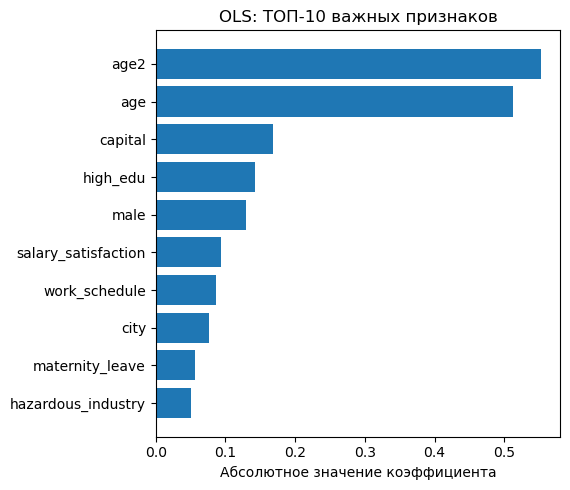

In [202]:
# Визуализация
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
top_10 = ols_coef.head(10)
plt.barh(range(10), top_10['importance_abs'])
plt.yticks(range(10), top_10['feature'])
plt.xlabel('Абсолютное значение коэффициента')
plt.title('OLS: ТОП-10 важных признаков')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Lasso

In [204]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso(max_iter=10000)
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

best_alpha = grid_search.best_params_['alpha']
print(f"\nОптимальный alpha (сила регуляризации): {best_alpha}")


Оптимальный alpha (сила регуляризации): 0.001


In [205]:

lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(X_scaled, y)
y_pred_lasso = lasso.predict(X_scaled)


rmse_lasso = np.sqrt(mean_squared_error(y, y_pred_lasso))
mae_lasso = mean_absolute_error(y, y_pred_lasso)
r2_lasso = r2_score(y, y_pred_lasso)


all_metrics['LASSO'] = {
    'RMSE': rmse_lasso,
    'MAE': mae_lasso,
    'R2': r2_lasso
}

In [206]:

lasso_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_,
    'importance_abs': np.abs(lasso.coef_)
}).sort_values('importance_abs', ascending=False)

all_coefficients['LASSO'] = lasso_coef

In [207]:
# Анализ обнуленных признаков
zero_features = np.sum(lasso.coef_ == 0)
total_features = len(lasso.coef_)

print(f"RMSE: {rmse_lasso:.4f}")
print(f"MAE: {mae_lasso:.4f}")
print(f"R²: {r2_lasso:.4f}")
print(f"Обнулено признаков: {zero_features} из {total_features} ({zero_features/total_features*100:.1f}%)")
print(f"\nТоп-5 важных признаков:")
print(lasso_coef[lasso_coef['coefficient'] != 0].head(5).to_string(index=False))

RMSE: 0.4278
MAE: 0.3306
R²: 0.4061
Обнулено признаков: 0 из 26 (0.0%)

Топ-5 важных признаков:
 feature  coefficient  importance_abs
    age2        -0.46            0.46
     age         0.42            0.42
 capital         0.17            0.17
high_edu         0.13            0.13
    male         0.13            0.13


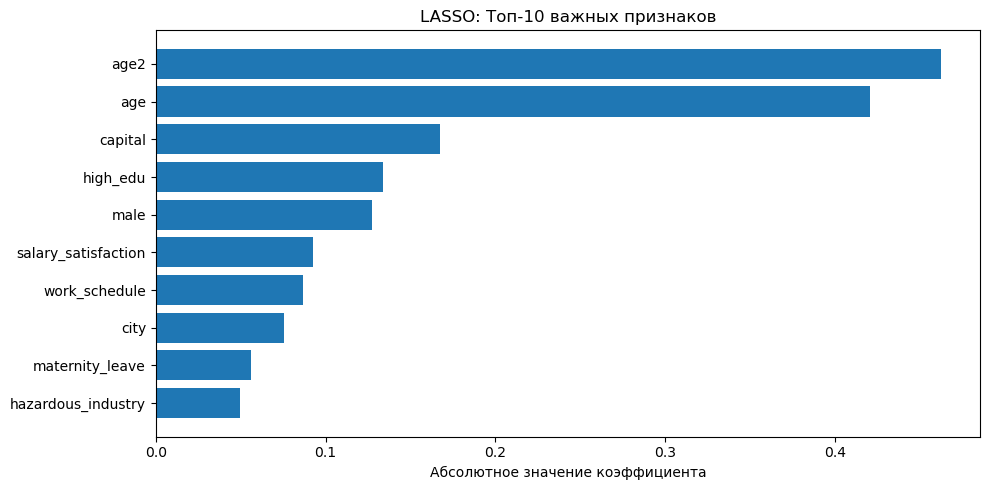

In [208]:
plt.figure(figsize=(10, 5))

lasso_nonzero = lasso_coef[lasso_coef['coefficient'] != 0].head(10)
if len(lasso_nonzero) > 0:
    
    plt.barh(range(len(lasso_nonzero)), lasso_nonzero['importance_abs'])
    plt.yticks(range(len(lasso_nonzero)), lasso_nonzero['feature'])
    plt.xlabel('Абсолютное значение коэффициента')
    plt.title(f'LASSO: Топ-{len(lasso_nonzero)} важных признаков')
    plt.gca().invert_yaxis()
else:
    plt.text(0.5, 0.5, 'Все признаки обнулены', ha='center', va='center')

plt.tight_layout()
plt.show()

## Ridge

In [210]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_alpha = grid_search.best_params_['alpha']
print(f"Оптимальный alpha для Ridge: {best_alpha}")

Оптимальный alpha для Ridge: 1


In [211]:
ridge = Ridge(alpha=best_alpha)
ridge.fit(X_scaled, y)
y_pred_ridge = ridge.predict(X_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y, y_pred_ridge))
mae_ridge = mean_absolute_error(y, y_pred_ridge)
r2_ridge = r2_score(y, y_pred_ridge)

all_metrics['RIDGE'] = {
    'RMSE': rmse_ridge,
    'MAE': mae_ridge,
    'R2': r2_ridge
}

In [212]:
ridge_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ridge.coef_,
    'importance_abs': np.abs(ridge.coef_)
}).sort_values('importance_abs', ascending=False)

all_coefficients['RIDGE'] = ridge_coef

# Вывод
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE: {mae_ridge:.4f}")
print(f"R²: {r2_ridge:.4f}")
print(f"\nТоп-5 важных признаков:")
print(ridge_coef.head(5).to_string(index=False))

RMSE: 0.4275
MAE: 0.3305
R²: 0.4068

Топ-5 важных признаков:
 feature  coefficient  importance_abs
    age2        -0.54            0.54
     age         0.50            0.50
 capital         0.17            0.17
high_edu         0.14            0.14
    male         0.13            0.13


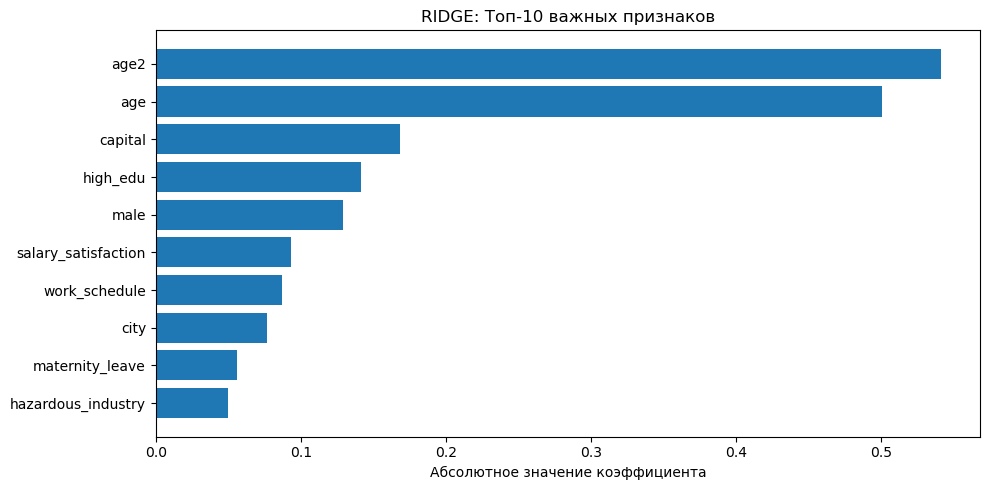

In [213]:
plt.figure(figsize=(10, 5))


top_10_ridge = ridge_coef.head(10)
plt.barh(range(10), top_10_ridge['importance_abs'])
plt.yticks(range(10), top_10_ridge['feature'])
plt.xlabel('Абсолютное значение коэффициента')
plt.title('RIDGE: Топ-10 важных признаков')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Ансамблиевые модели

Помимо линейных моделей, имеющих простую интерпретацию, имеет смысл оценить потенциал деревьев решений. Decision Tree строит последовательные правила разделения выборки, что позволяет моделировать нелинейные эффекты без предварительного преобразования переменных. Однако отдельное дерево склонно к переобучению. Для повышения точности и устойчивости мы обратимся также к Random Forest — ансамблю из множества деревьев, где каждое обучается на случайной подвыборке данных и случайном подмножестве признаков. 

### Decision Tree Regression

In [216]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeRegressor(random_state=42)
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_
print(f"Лучшие параметры: {grid_search_dt.best_params_}")

Лучшие параметры: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20}


In [217]:
y_pred_dt = best_dt.predict(X_test)
metrics_dt = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    'MAE': mean_absolute_error(y_test, y_pred_dt),
    'R2': r2_score(y_test, y_pred_dt)
}

all_metrics['Decision Tree'] = metrics_dt

In [218]:
dt_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)
all_features_importance = {}  
all_features_importance['Decision Tree'] = dt_importance

In [219]:
print(f"\nМетрики на тесте:")
print(f"RMSE: {metrics_dt['RMSE']:.2f}")
print(f"MAE: {metrics_dt['MAE']:.2f}")
print(f"R²: {metrics_dt['R2']:.4f}")

print("\nТоп-10 важных признаков:")
print(dt_importance.head(10).to_string(index=False))


Метрики на тесте:
RMSE: 0.47
MAE: 0.36
R²: 0.2405

Топ-10 важных признаков:
            feature  importance
            capital        0.22
               male        0.18
      work_schedule        0.15
           high_edu        0.12
salary_satisfaction        0.10
                age        0.09
               age2        0.03
               city        0.02
    high_qualifited        0.02
     marital_status        0.01


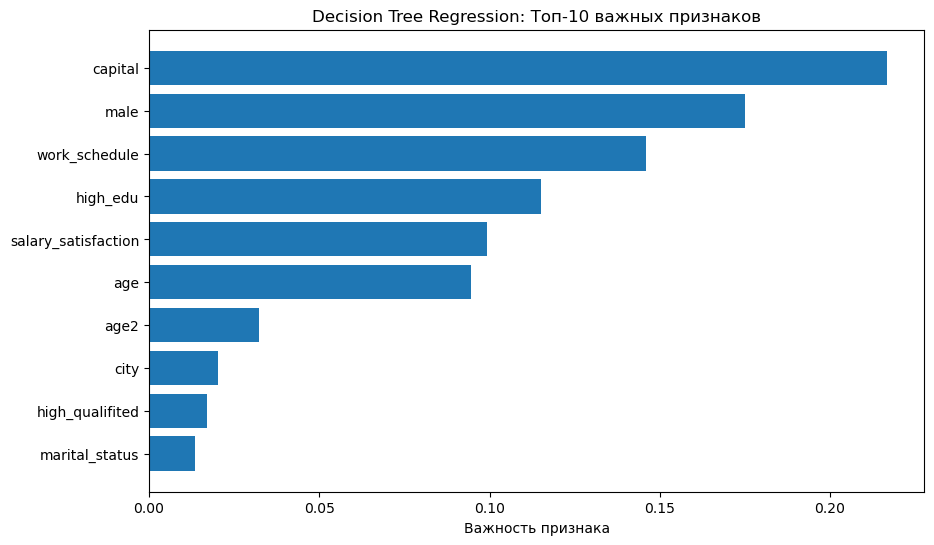

In [220]:
plt.figure(figsize=(10, 6))
top_features_dt = dt_importance.head(10)
plt.barh(range(10), top_features_dt['importance'])
plt.yticks(range(10), top_features_dt['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Важность признака')
plt.title('Decision Tree Regression: Топ-10 важных признаков')
plt.show()

### Random Forest Regression

In [222]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print(f"Лучшие параметры: {grid_search_rf.best_params_}")

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [223]:
y_pred_rf = best_rf.predict(X_test)
metrics_rf = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}

all_metrics['Random Forest'] = metrics_rf

In [224]:
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

all_features_importance['Random Forest'] = rf_importance

In [225]:
print(f"\nМетрики на тесте:")
print(f"RMSE: {metrics_rf['RMSE']:.4f}")
print(f"MAE: {metrics_rf['MAE']:.4f}")
print(f"R²: {metrics_rf['R2']:.4f}")

print("\nТоп-10 важных признаков:")
print(rf_importance.head(10).to_string(index=False))


Метрики на тесте:
RMSE: 0.4287
MAE: 0.3246
R²: 0.3550

Топ-10 важных признаков:
                         feature  importance
                   work_schedule        0.12
                            age2        0.12
                             age        0.11
                         capital        0.10
                            male        0.08
             salary_satisfaction        0.05
                        high_edu        0.05
                            kids        0.04
                            city        0.03
financial_situation_satisfaction        0.03


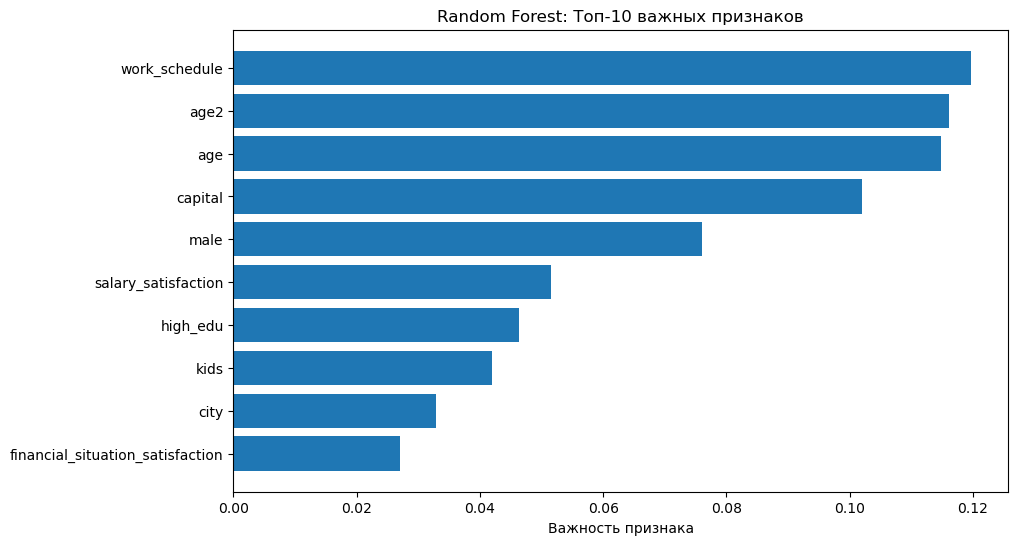

In [226]:
plt.figure(figsize=(10, 6))
top_features = rf_importance.head(10)
plt.barh(range(10), top_features['importance'])
plt.yticks(range(10), top_features['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Важность признака')
plt.title('Random Forest: Топ-10 важных признаков')
plt.show()

## Бустинговые модели

В отличие от Random Forest, где деревья строятся независимо и параллельно, бустинговые методы обучают деревья последовательно — каждое следующее исправляет ошибки предыдущих. Gradient Boosting реализует эту идею через градиентный спуск, минимизируя функцию потерь. Его оптимизированная версия — XGBoost — содержит множество улучшений (регуляризация, обработка пропусков, параллелизация) и считается одним из самых эффективных алгоритмов для табличных данных.

### Gradient Boosting

In [229]:
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)
grid_search_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
grid_search_gb.fit(X_train, y_train)

best_gb = grid_search_gb.best_estimator_
print(f"Лучшие параметры: {grid_search_gb.best_params_}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}


In [230]:
y_pred_gb = best_gb.predict(X_test)
metrics_gb = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb)
}

all_metrics['Gradient Boosting'] = metrics_gb

In [231]:
gb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

all_features_importance['Gradient Boosting'] = gb_importance

In [232]:
print(f"\nМетрики на тесте:")
print(f"RMSE: {metrics_gb['RMSE']:.2f}")
print(f"MAE: {metrics_gb['MAE']:.2f}")
print(f"R²: {metrics_gb['R2']:.4f}")

print("\nТоп-10 важных признаков:")
print(gb_importance.head(10).to_string(index=False))


Метрики на тесте:
RMSE: 0.43
MAE: 0.33
R²: 0.3564

Топ-10 важных признаков:
                         feature  importance
                   work_schedule        0.16
                         capital        0.15
                            male        0.11
                        high_edu        0.08
                            age2        0.07
             salary_satisfaction        0.07
                             age        0.07
                            city        0.04
financial_situation_satisfaction        0.02
                 high_qualifited        0.02


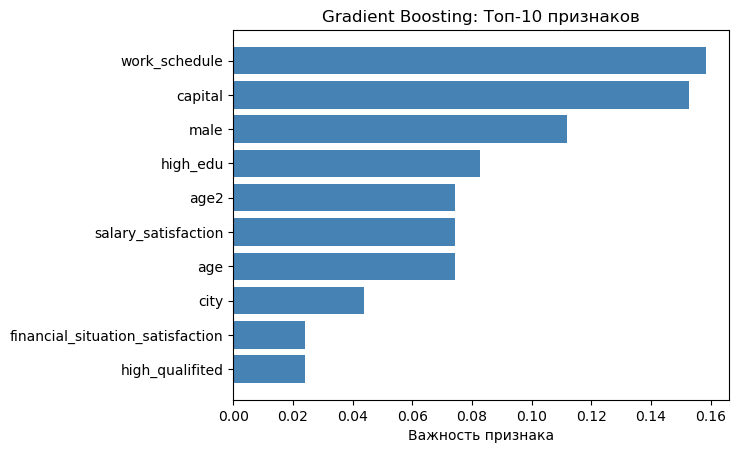

In [233]:
gb_top10 = all_features_importance['Gradient Boosting'].head(10)
plt.barh(range(10), gb_top10['importance'], color='steelblue')
plt.yticks(range(10), gb_top10['feature'])
plt.xlabel('Важность признака')
plt.title('Gradient Boosting: Топ-10 признаков')
plt.gca().invert_yaxis()

### XGBoost

In [235]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
grid_search_xgb.fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_
print(f"Лучшие параметры: {grid_search_xgb.best_params_}")

Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [236]:
y_pred_xgb = best_xgb.predict(X_test)
metrics_xgb = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'R2': r2_score(y_test, y_pred_xgb)
}

all_metrics['XGBoost'] = metrics_xgb

In [237]:
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

all_features_importance['XGBoost'] = xgb_importance

In [238]:
print(f"\nМетрики на тесте:")
print(f"RMSE: {metrics_xgb['RMSE']:.2f}")
print(f"MAE: {metrics_xgb['MAE']:.2f}")
print(f"R²: {metrics_xgb['R2']:.4f}")

print("\nТоп-10 важных признаков:")
print(xgb_importance.head(10).to_string(index=False))


Метрики на тесте:
RMSE: 0.43
MAE: 0.33
R²: 0.3613

Топ-10 важных признаков:
                         feature  importance
                         capital        0.15
                            male        0.10
             salary_satisfaction        0.10
                        high_edu        0.10
                            city        0.06
                      self_owner        0.05
                 high_qualifited        0.04
financial_situation_satisfaction        0.04
                 maternity_leave        0.04
                   work_schedule        0.04


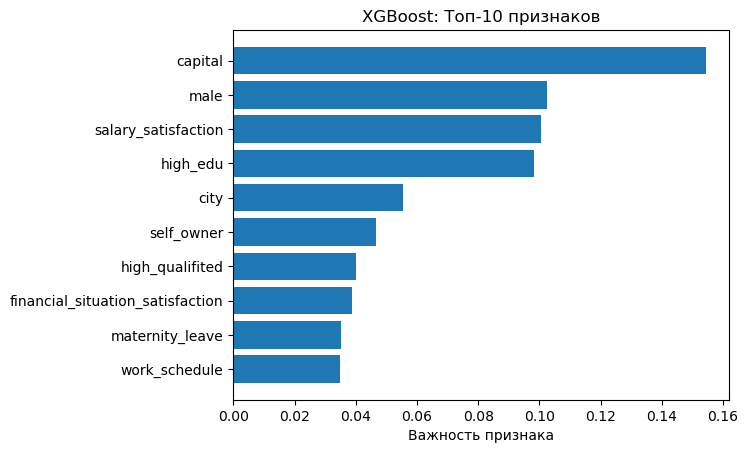

In [239]:
xgb_top10 = all_features_importance['XGBoost'].head(10)
plt.barh(range(10), xgb_top10['importance'])
plt.yticks(range(10), xgb_top10['feature'])
plt.xlabel('Важность признака')
plt.title('XGBoost: Топ-10 признаков')
plt.gca().invert_yaxis()

## Результаты

После того как мы обучили пять типов моделей (OLS, LASSO, Ridge, Random Forest, Gradient Boosting, XGBoost), необходимо объективно сравнить их точность. Для этого используем стандартные метрики регрессии — RMSE (среднеквадратичную ошибку) и MAE (среднюю абсолютную ошибку). Интересно не просто определить лучшую модель, но и понять, насколько значим выигрыш от использования сложных ансамблевых методов по сравнению с простой линейной регрессией. Это позволит сделать вывод о структуре зависимостей в наших данных: преобладают ли линейные связи или есть сложные нелинейные эффекты.

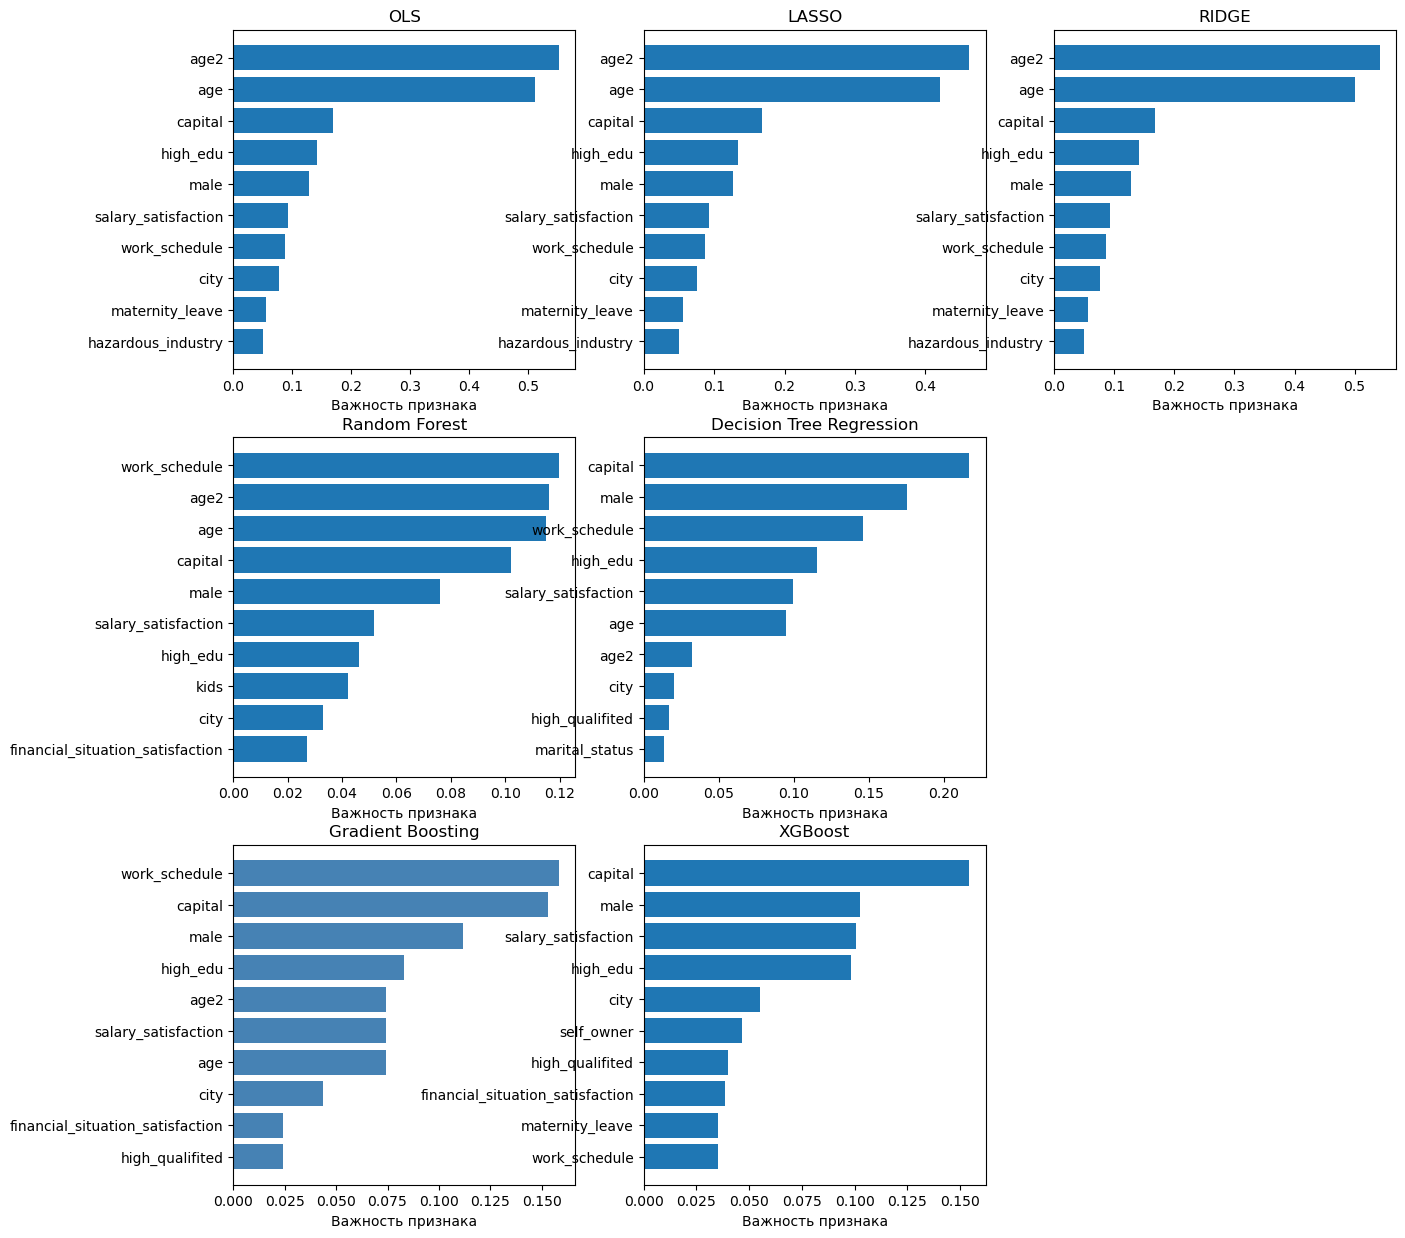

In [241]:
plt.figure(figsize=(15, 15))
plt.subplot(3, 3, 1)
top_10 = ols_coef.head(10)
plt.barh(range(10), top_10['importance_abs'])
plt.yticks(range(10), top_10['feature'])
plt.xlabel('Важность признака')
plt.title('OLS')
plt.gca().invert_yaxis()

plt.subplot(3, 3, 2)
plt.barh(range(len(lasso_nonzero)), lasso_nonzero['importance_abs'])
plt.yticks(range(len(lasso_nonzero)), lasso_nonzero['feature'])
plt.xlabel('Важность признака')
plt.title(f'LASSO')
plt.gca().invert_yaxis()

plt.subplot(3, 3, 3)
plt.barh(range(10), top_10_ridge['importance_abs'])
plt.yticks(range(10), top_10_ridge['feature'])
plt.xlabel('Важность признака')
plt.title('RIDGE')
plt.gca().invert_yaxis()

plt.subplot(3, 3, 4)
plt.barh(range(10), top_features['importance'])
plt.yticks(range(10), top_features['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Важность признака')
plt.title('Random Forest')

plt.subplot(3, 3, 5)
plt.barh(range(10), top_features_dt['importance'])
plt.yticks(range(10), top_features_dt['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Важность признака')
plt.title('Decision Tree Regression')

plt.subplot(3, 3, 7)
plt.barh(range(10), gb_top10['importance'], color='steelblue')
plt.yticks(range(10), gb_top10['feature'])
plt.xlabel('Важность признака')
plt.title('Gradient Boosting')
plt.gca().invert_yaxis()

plt.subplot(3, 3, 8)
plt.barh(range(10), xgb_top10['importance'])
plt.yticks(range(10), xgb_top10['feature'])
plt.xlabel('Важность признака')
plt.title('XGBoost')
plt.gca().invert_yaxis()

In [242]:
all_models = ['OLS', 'LASSO', 'RIDGE', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
full_metrics_df = pd.DataFrame({model: all_metrics.get(model, {}) for model in all_models}).T
full_metrics_df = full_metrics_df[['RMSE', 'MAE']]
full_metrics_df_sorted = full_metrics_df.sort_values('RMSE', ascending=True)


pd.set_option('display.float_format', '{:.5f}'.format)
full_metrics_df_sorted

,RMSE,MAE
XGBoost,0.42659,0.32614
OLS,0.42753,0.33052
RIDGE,0.42754,0.33050
LASSO,0.42779,0.33056
Gradient Boosting,0.42820,0.32776
Random Forest,0.42868,0.32464
Decision Tree,0.46518,0.35557


Для ваших данных сложность модели практически не дает выигрыша в точности. Простые линейные модели работают так же хорошо, как современные ансамблевые алгоритмы.
Тот факт, что OLS ≈ RIDGE ≈ LASSO, говорит о:
- Отсутствии серьезной мультиколлинеарности между признаками
- Преобладании линейных зависимостей зарплаты от факторов
- Эффективности простых моделей для вашего набора данных


# Кластеризация

Для более глубокого понимания структуры рынка труда мы хотим выделить однородные группы работников со схожими социально-экономическими характеристиками. Это позволит, например, увидеть, какие кластеры наиболее уязвимы с точки зрения низких доходов, а какие, наоборот, являются привилегированными. Для этого применим алгоритм k-means. 

Для начала нужно ответить на ключевой вопрос: на сколько кластеров делить данные? Используем два дополняющих друг друга метода — метод локтя (оценивающий внутрикластерную сумму квадратов) и силуэтный коэффициент (оценивающий компактность и разделимость кластеров). Выберем число k, на котором оба метода дают согласованный результат.

In [245]:
X_cluster = rdf.drop('log_salary', axis=1).copy()

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Данные для кластеризации: {X_scaled.shape}")
print(f"Признаки: {list(X_cluster.columns)}")

Данные для кластеризации: (4278, 26)
Признаки: ['male', 'age', 'age2', 'capital', 'city', 'urban_type', 'marital_status', 'secondary_edu', 'proff_edu', 'high_edu', 'high_qualifited', 'maternity_leave', 'kids', 'labour_conditions_satisfaction', 'salary_satisfaction', 'promotion_satisfaction', 'work_schedule', 'hazardous_industry', 'state_owner', 'self_owner', 'management_trust', 'new_job_confidence', 'life_satisfaction', 'financial_situation_satisfaction', 'foreign_language', 'health']


In [246]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
  
    
    if k > 1:
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    else:
        silhouette_scores.append(0)

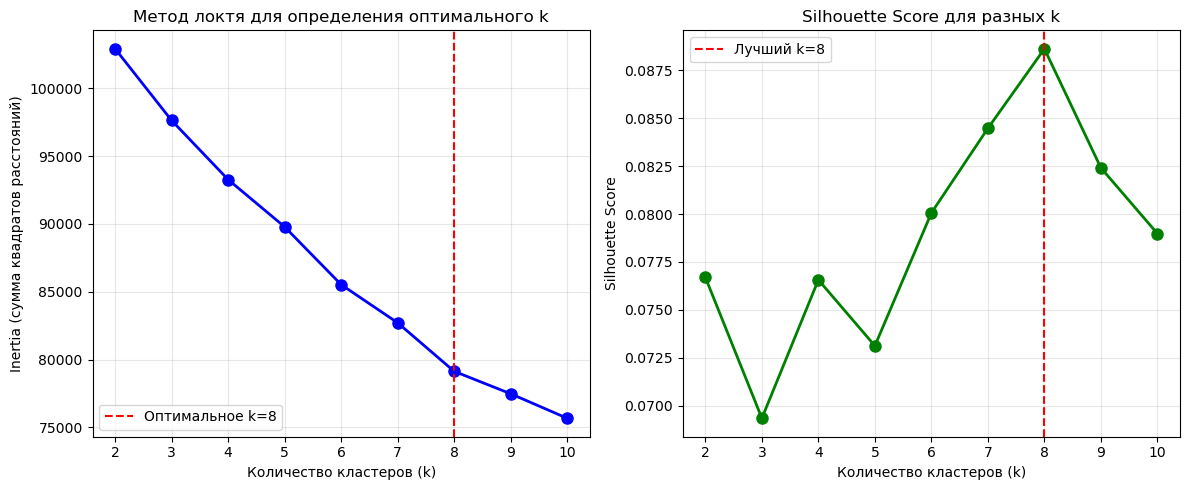

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Inertia (сумма квадратов расстояний)')
axes[0].set_title('Метод локтя для определения оптимального k')
axes[0].grid(True, alpha=0.3)

inertia_diff = np.diff(inertia)
inertia_diff_ratio = inertia_diff[1:] / inertia_diff[:-1]


elbow_point = np.where(inertia_diff_ratio < 0.5)[0]
optimal_k_elbow = elbow_point[0] + 3 if len(elbow_point) > 0 else 4

axes[0].axvline(x=optimal_k_elbow, color='red', linestyle='--', 
                label=f'Оптимальное k={optimal_k_elbow}')
axes[0].legend()

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score для разных k')
axes[1].grid(True, alpha=0.3)

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=optimal_k_silhouette, color='red', linestyle='--',
                label=f'Лучший k={optimal_k_silhouette}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [248]:
optimal_k = optimal_k_silhouette  
print(f"Рекомендованное количество кластеров: {optimal_k}")
print(f"  - По методу локтя: {optimal_k_elbow}")
print(f"  - По silhouette score: {optimal_k_silhouette}")

Рекомендованное количество кластеров: 8
  - По методу локтя: 8
  - По silhouette score: 8


In [249]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels
df_clustered['cluster'] = df_clustered['cluster'].astype('category')

print(f"\nКластеризация завершена. Распределение по кластерам:")
cluster_counts = df_clustered['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Кластер {cluster+1}: {count} записей ({count/len(df_clustered)*100:.1f}%)")


Кластеризация завершена. Распределение по кластерам:
  Кластер 1: 49 записей (1.1%)
  Кластер 2: 759 записей (17.7%)
  Кластер 3: 693 записей (16.2%)
  Кластер 4: 749 записей (17.5%)
  Кластер 5: 308 записей (7.2%)
  Кластер 6: 680 записей (15.9%)
  Кластер 7: 924 записей (21.6%)
  Кластер 8: 116 записей (2.7%)


In [250]:
cluster_summary = df_clustered.groupby('cluster').mean().round(2)
cluster_summary['salary'] = np.exp(cluster_summary['log_salary'])
cluster_summary['count'] = cluster_counts
cluster_summary['percentage'] = (cluster_summary['count'] / len(df_clustered) * 100).round(1)

print("\nСредние значения по кластерам:")
cluster_summary


Средние значения по кластерам:


,male,age,age2,capital,city,urban_type,marital_status,secondary_edu,proff_edu,high_edu,high_qualifited,maternity_leave,kids,labour_conditions_satisfaction,salary_satisfaction,promotion_satisfaction,work_schedule,hazardous_industry,state_owner,self_owner,management_trust,new_job_confidence,life_satisfaction,financial_situation_satisfaction,foreign_language,health,experience,experience^2,log_salary,salary,count,percentage
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.00000,32.06000,1064.15000,0.18000,0.80000,0.06000,0.82000,0.14000,0.22000,0.59000,0.04000,1.00000,1.57000,0.82000,0.43000,0.71000,41.57000,0.08000,0.49000,0.00000,0.76000,0.49000,0.90000,0.31000,0.41000,0.65000,9.60000,128.88000,9.92000,20332.99063,49,1.10000
1,0.55000,29.35000,903.58000,0.25000,0.86000,0.00000,0.19000,0.12000,0.39000,0.38000,0.01000,0.00000,0.23000,0.91000,0.52000,0.69000,43.03000,0.13000,0.32000,0.00000,0.82000,0.67000,0.74000,0.32000,0.42000,0.79000,7.31000,89.67000,10.54000,37797.56645,759,17.70000
2,0.54000,44.88000,2124.20000,0.17000,0.80000,0.00000,0.57000,0.39000,0.24000,0.23000,0.02000,0.00000,1.31000,0.08000,0.06000,0.09000,44.87000,0.10000,0.30000,0.00000,0.45000,0.38000,0.28000,0.06000,0.11000,0.31000,20.48000,536.57000,10.40000,32859.62567,693,16.20000
3,0.59000,49.15000,2519.41000,0.13000,0.72000,0.00000,0.63000,0.92000,0.00000,0.00000,0.02000,0.00000,1.60000,0.94000,0.48000,0.72000,44.59000,0.11000,0.37000,0.00000,0.86000,0.36000,0.67000,0.32000,0.04000,0.44000,24.97000,754.27000,10.38000,32208.96149,749,17.50000
4,0.43000,44.89000,2164.52000,0.23000,0.00000,1.00000,0.53000,0.35000,0.26000,0.34000,0.04000,0.00000,1.43000,0.81000,0.55000,0.67000,41.76000,0.16000,0.46000,0.00000,0.84000,0.53000,0.56000,0.23000,0.23000,0.58000,20.11000,553.19000,10.42000,33523.43415,308,7.20000
5,0.33000,51.14000,2704.69000,0.14000,0.70000,0.00000,0.67000,0.00000,0.94000,0.00000,0.02000,0.00000,1.63000,0.89000,0.41000,0.73000,40.85000,0.14000,0.53000,0.00000,0.84000,0.31000,0.68000,0.23000,0.06000,0.41000,27.28000,858.26000,10.29000,29436.77435,680,15.90000
6,0.32000,47.23000,2332.11000,0.21000,0.85000,0.00000,0.71000,0.00000,0.00000,0.99000,0.14000,0.00000,1.55000,0.95000,0.53000,0.75000,40.36000,0.17000,0.60000,0.00000,0.87000,0.38000,0.73000,0.34000,0.38000,0.47000,23.73000,672.34000,10.68000,43477.55035,924,21.60000
7,0.63000,44.97000,2130.41000,0.12000,0.80000,0.08000,0.67000,0.20000,0.26000,0.46000,0.34000,0.00000,1.42000,0.90000,0.65000,0.75000,42.78000,0.01000,0.03000,1.00000,0.78000,0.50000,0.66000,0.40000,0.36000,0.57000,20.62000,558.11000,10.92000,55270.79894,116,2.70000


In [251]:
cluster_summary = df_clustered.groupby('cluster').median().round(2)
cluster_summary['salary'] = np.exp(cluster_summary['log_salary'])
cluster_summary['count'] = cluster_counts
cluster_summary['percentage'] = (cluster_summary['count'] / len(df_clustered) * 100).round(1)

print("Медианные значения по кластерам:")
cluster_summary

Медианные значения по кластерам:


,male,age,age2,capital,city,urban_type,marital_status,secondary_edu,proff_edu,high_edu,high_qualifited,maternity_leave,kids,labour_conditions_satisfaction,salary_satisfaction,promotion_satisfaction,work_schedule,hazardous_industry,state_owner,self_owner,management_trust,new_job_confidence,life_satisfaction,financial_situation_satisfaction,foreign_language,health,experience,experience^2,log_salary,salary,count,percentage
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.00000,32.50000,1056.25000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,1.00000,0.00000,1.00000,1.00000,1.00000,0.00000,1.00000,40.00000,0.00000,0.00000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,1.00000,9.00000,81.00000,9.90000,19930.37044,49,1.10000
1,1.00000,28.50000,812.25000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,1.00000,40.00000,0.00000,0.00000,0.00000,1.00000,1.00000,1.00000,0.00000,0.00000,1.00000,6.00000,36.00000,10.60000,40134.83743,759,17.70000
2,1.00000,44.50000,1980.25000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,40.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,20.00000,400.00000,10.40000,32859.62567,693,16.20000
3,1.00000,49.00000,2401.00000,0.00000,1.00000,0.00000,1.00000,1.00000,0.00000,0.00000,0.00000,0.00000,2.00000,1.00000,0.00000,1.00000,40.00000,0.00000,0.00000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,25.00000,625.00000,10.37000,31888.47697,749,17.50000
4,0.00000,44.50000,1980.25000,0.00000,0.00000,1.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,1.00000,1.00000,40.00000,0.00000,0.00000,0.00000,1.00000,1.00000,1.00000,0.00000,0.00000,1.00000,19.00000,361.00000,10.43000,33860.35026,308,7.20000
5,0.00000,51.50000,2652.25000,0.00000,1.00000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,2.00000,1.00000,0.00000,1.00000,40.00000,0.00000,1.00000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,28.00000,784.00000,10.31000,30031.43664,680,15.90000
6,0.00000,46.50000,2162.25000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,1.00000,0.00000,0.00000,2.00000,1.00000,1.00000,1.00000,40.00000,0.00000,1.00000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,22.36000,499.75000,10.63000,41357.12520,924,21.60000
7,1.00000,45.50000,2070.25000,0.00000,1.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,1.00000,1.00000,40.00000,0.00000,0.00000,1.00000,1.00000,0.50000,1.00000,0.00000,0.00000,1.00000,20.50000,420.50000,10.82000,50011.08701,116,2.70000


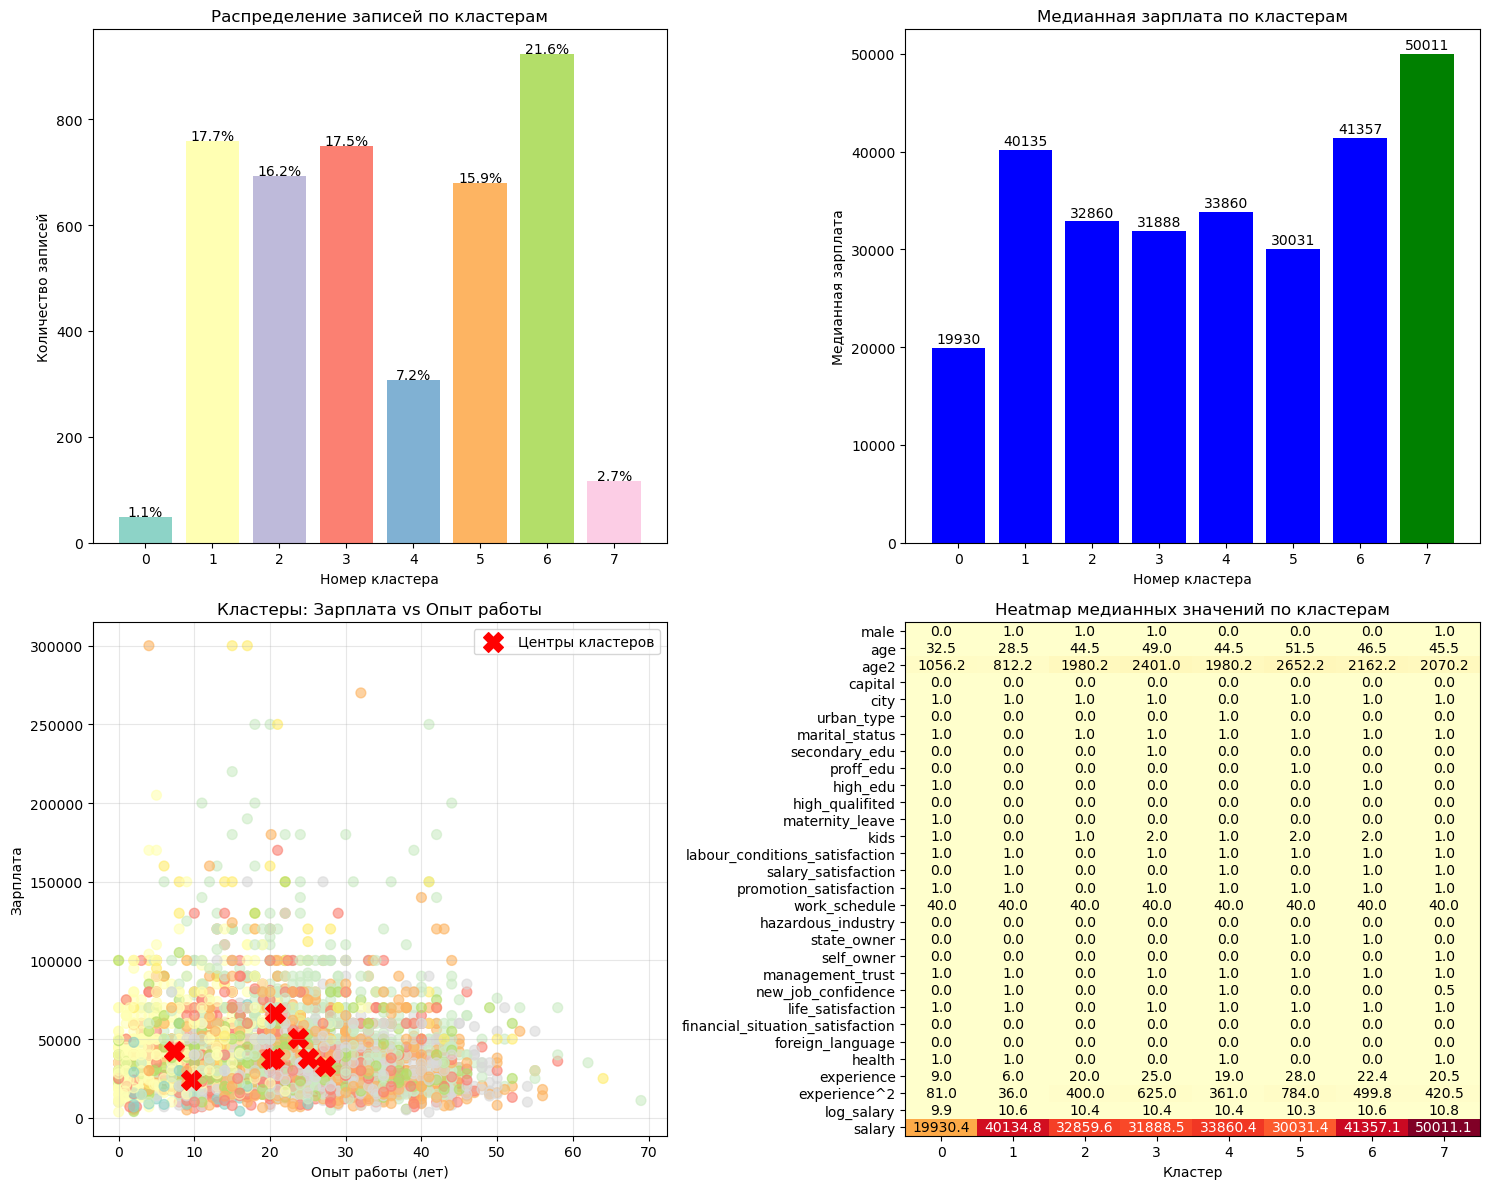

In [252]:
cluster_summary['salary'] = np.exp(cluster_summary['log_salary'])
df_clustered['salary'] = np.exp(df_clustered['log_salary'])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))


axes[0, 0].bar(cluster_summary.index, cluster_summary['count'], 
               color=plt.cm.Set3(range(optimal_k)))
axes[0, 0].set_xlabel('Номер кластера')
axes[0, 0].set_ylabel('Количество записей')
axes[0, 0].set_title('Распределение записей по кластерам')
for i, (idx, row) in enumerate(cluster_summary.iterrows()):
    axes[0, 0].text(idx, row['count'] + 2, f"{row['percentage']}%", 
                   ha='center', fontsize=10)


salary_by_cluster = cluster_summary['salary'].sort_values(ascending=False)
colors_salary = ['green' if i == salary_by_cluster.index[0] else 'blue' 
                for i in salary_by_cluster.index]

bars = axes[0, 1].bar(salary_by_cluster.index, salary_by_cluster.values, 
                      color=colors_salary)
axes[0, 1].set_xlabel('Номер кластера')
axes[0, 1].set_ylabel('Медианная зарплата')
axes[0, 1].set_title('Медианная зарплата по кластерам')


for bar, salary in zip(bars, salary_by_cluster.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                   f'{salary:.0f}', ha='center', fontsize=10)


scatter1 = axes[1, 0].scatter(df_clustered['experience'], 
                              df_clustered['salary'],
                              c=df_clustered['cluster'], 
                              cmap='Set3',
                              alpha=0.6,
                              s=50)
axes[1, 0].set_xlabel('Опыт работы (лет)')
axes[1, 0].set_ylabel('Зарплата')
axes[1, 0].set_title('Кластеры: Зарплата vs Опыт работы')
axes[1, 0].grid(True, alpha=0.3)


centers = df_clustered.groupby('cluster')[['experience', 'salary']].mean()
axes[1, 0].scatter(centers['experience'], centers['salary'],
                   c='red', s=200, marker='X', label='Центры кластеров')
axes[1, 0].legend()



heatmap_data = cluster_summary.drop(['count', 'percentage'], axis=1).T

im = axes[1, 1].imshow(heatmap_data, aspect='auto', cmap='YlOrRd')
axes[1, 1].set_xticks(range(len(heatmap_data.columns)))
axes[1, 1].set_yticks(range(len(heatmap_data.index)))
axes[1, 1].set_xticklabels(heatmap_data.columns)
axes[1, 1].set_yticklabels(heatmap_data.index)
axes[1, 1].set_xlabel('Кластер')
axes[1, 1].set_title('Heatmap медианных значений по кластерам')

# Добавляем значения в ячейки
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        text = axes[1, 1].text(j, i, f'{heatmap_data.iloc[i, j]:.1f}',
                              ha="center", va="center", 
                              color="black" if heatmap_data.iloc[i, j] < 
                              heatmap_data.values.max()/2 else "white")

plt.tight_layout()
plt.show()

Для визуализации применим метод главных компонент (PCA). Он создаёт два новых искусственных признака — PC1 и PC2 — которые являются направлениями максимальной изменчивости данных. Это позволяет спроецировать многомерные кластеры на плоскость и увидеть, насколько хорошо они разделяются. Важно помнить, что при этом часть информации теряется, но для целей наглядной демонстрации структуры данных PCA является стандартным и эффективным инструментом.

In [253]:
# Применяем PCA для сокращения до 2 измерений
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
pca_df['salary'] = np.exp(df['log_salary']).values

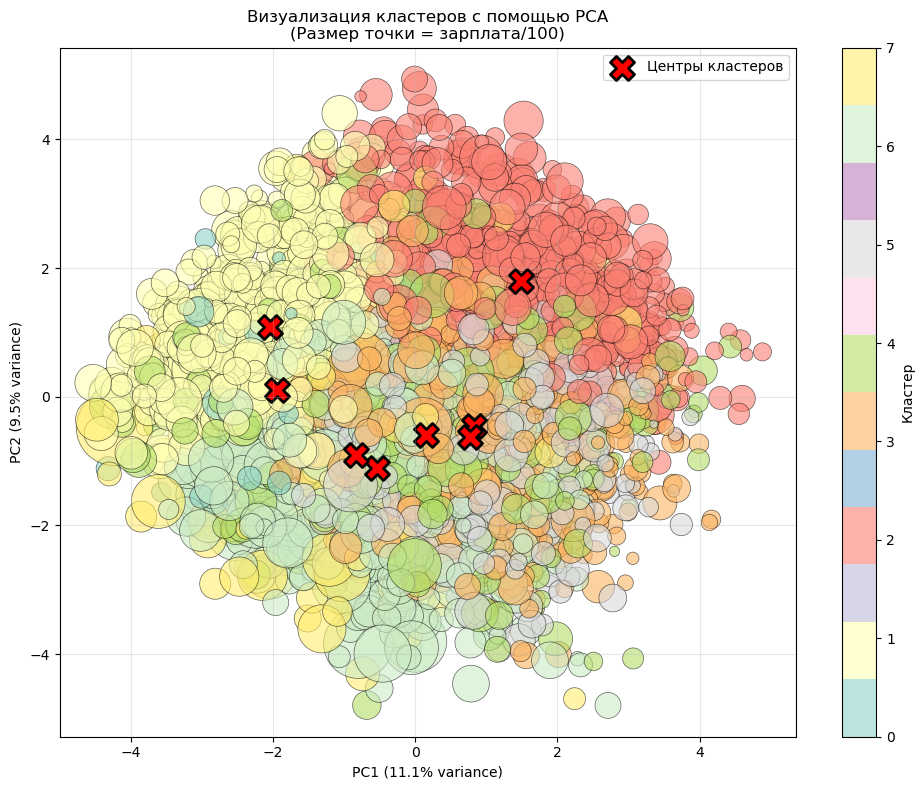

In [254]:
plt.figure(figsize=(10, 8))


scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['cluster'], 
                     cmap='Set3',
                     s=pca_df['salary']/100,  
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Визуализация кластеров с помощью PCA\n(Размер точки = зарплата/100)')
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)


centers_pca = pd.DataFrame({
    'PC1': pca_df.groupby('cluster')['PC1'].mean(),
    'PC2': pca_df.groupby('cluster')['PC2'].mean()
})

plt.scatter(centers_pca['PC1'], centers_pca['PC2'],
           c='red', s=300, marker='X', label='Центры кластеров',
           edgecolors='black', linewidth=2)

plt.legend()
plt.tight_layout()
plt.show()